## DeathMap

In [1]:
import os
import sys
import shutil
import math
import warnings
from typing import *
from enum import Enum
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
import shutil
import math
import warnings
from typing import *
from enum import Enum
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append("/home/esraan/CellDeathSpreading/")

from src.NucleationAndPropagationMeasurements import *
import seaborn as sns
from src.uSpiCalc import uSpiCalc
from src.mSpiCalc import mSpiCalc
from src.mixSpiCalc import mixSpiCalc
import seaborn as sns

In [2]:
exps_dir_name = '/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/mixed_pure_death_minutes_microns/'
meta_data_file_full_path= "/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/all_csv_files_minutes_microns_with_sytox.csv"
meta_data_extract_exp_names= pd.read_csv(meta_data_file_full_path)
exp_names = meta_data_extract_exp_names.iloc[:,1]

### original code

Mode
necrosis     309
apoptosis    237
Name: count, dtype: int64


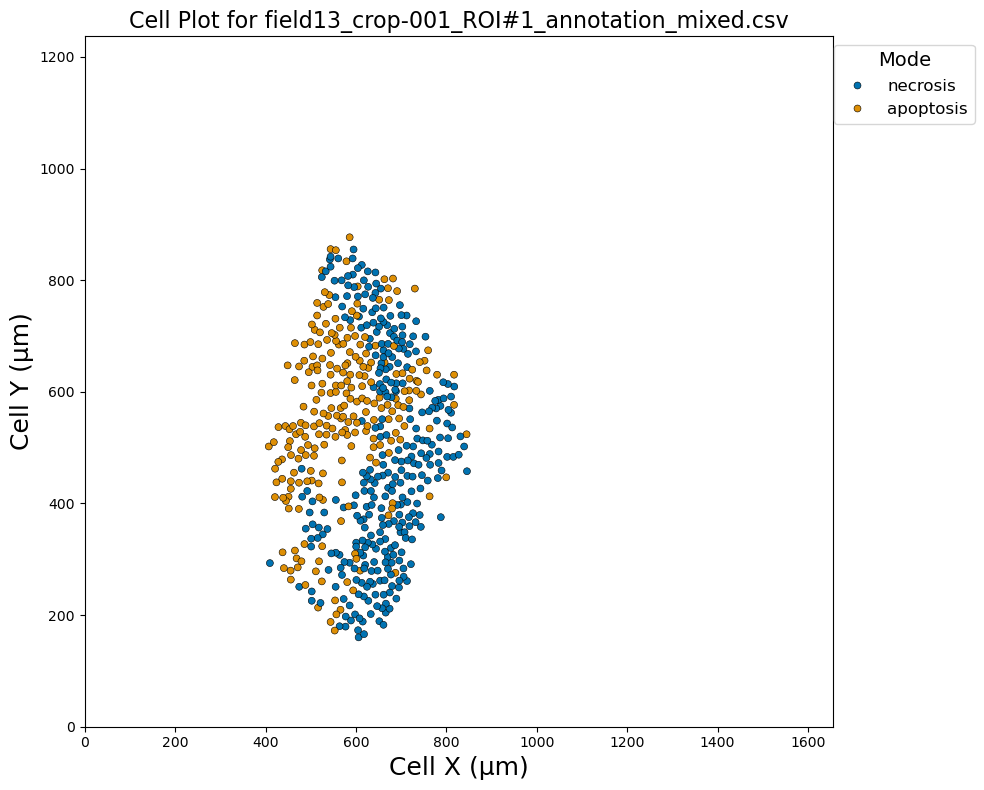

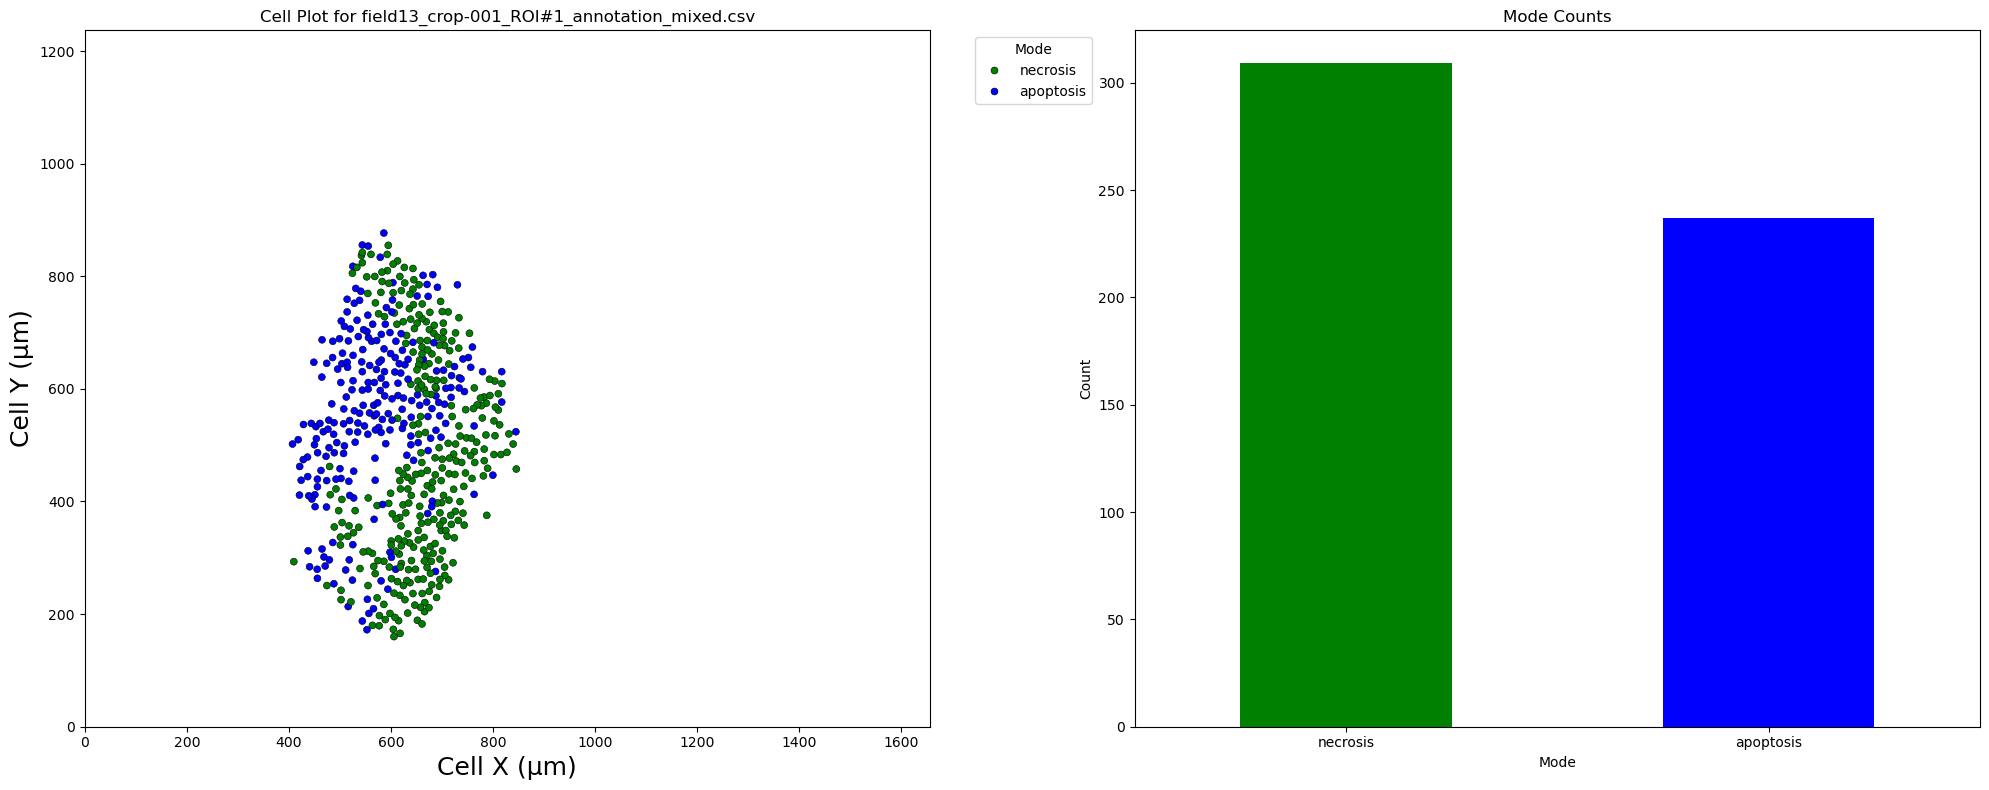

Mode
apoptosis    387
necrosis     249
Name: count, dtype: int64


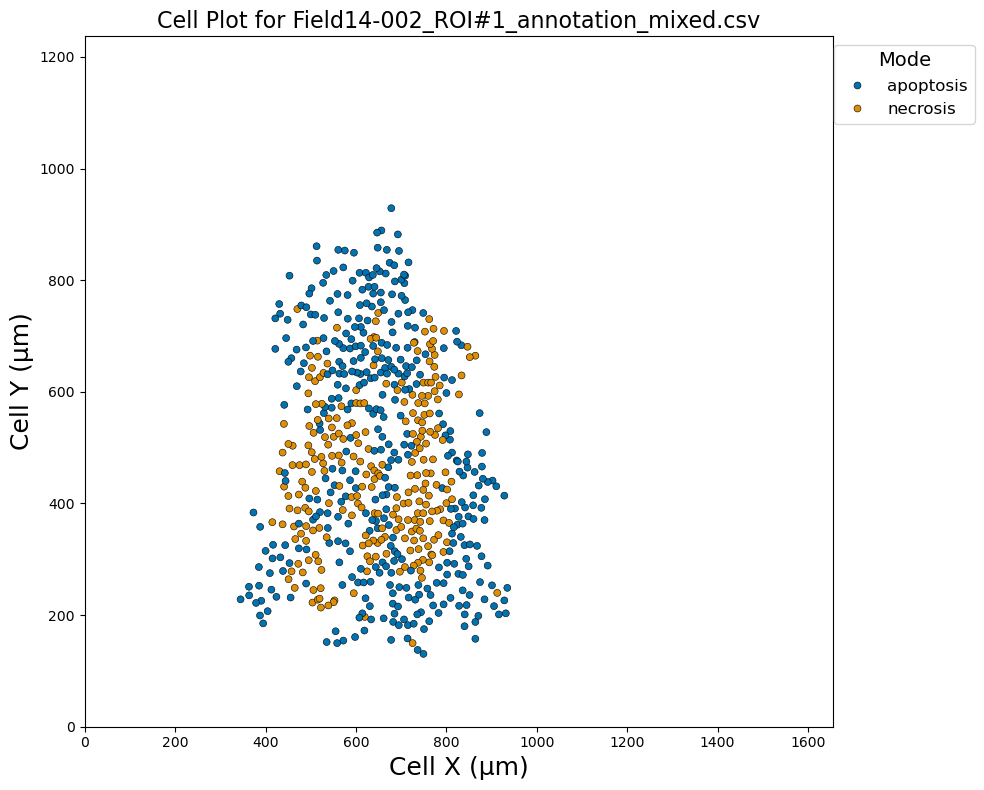

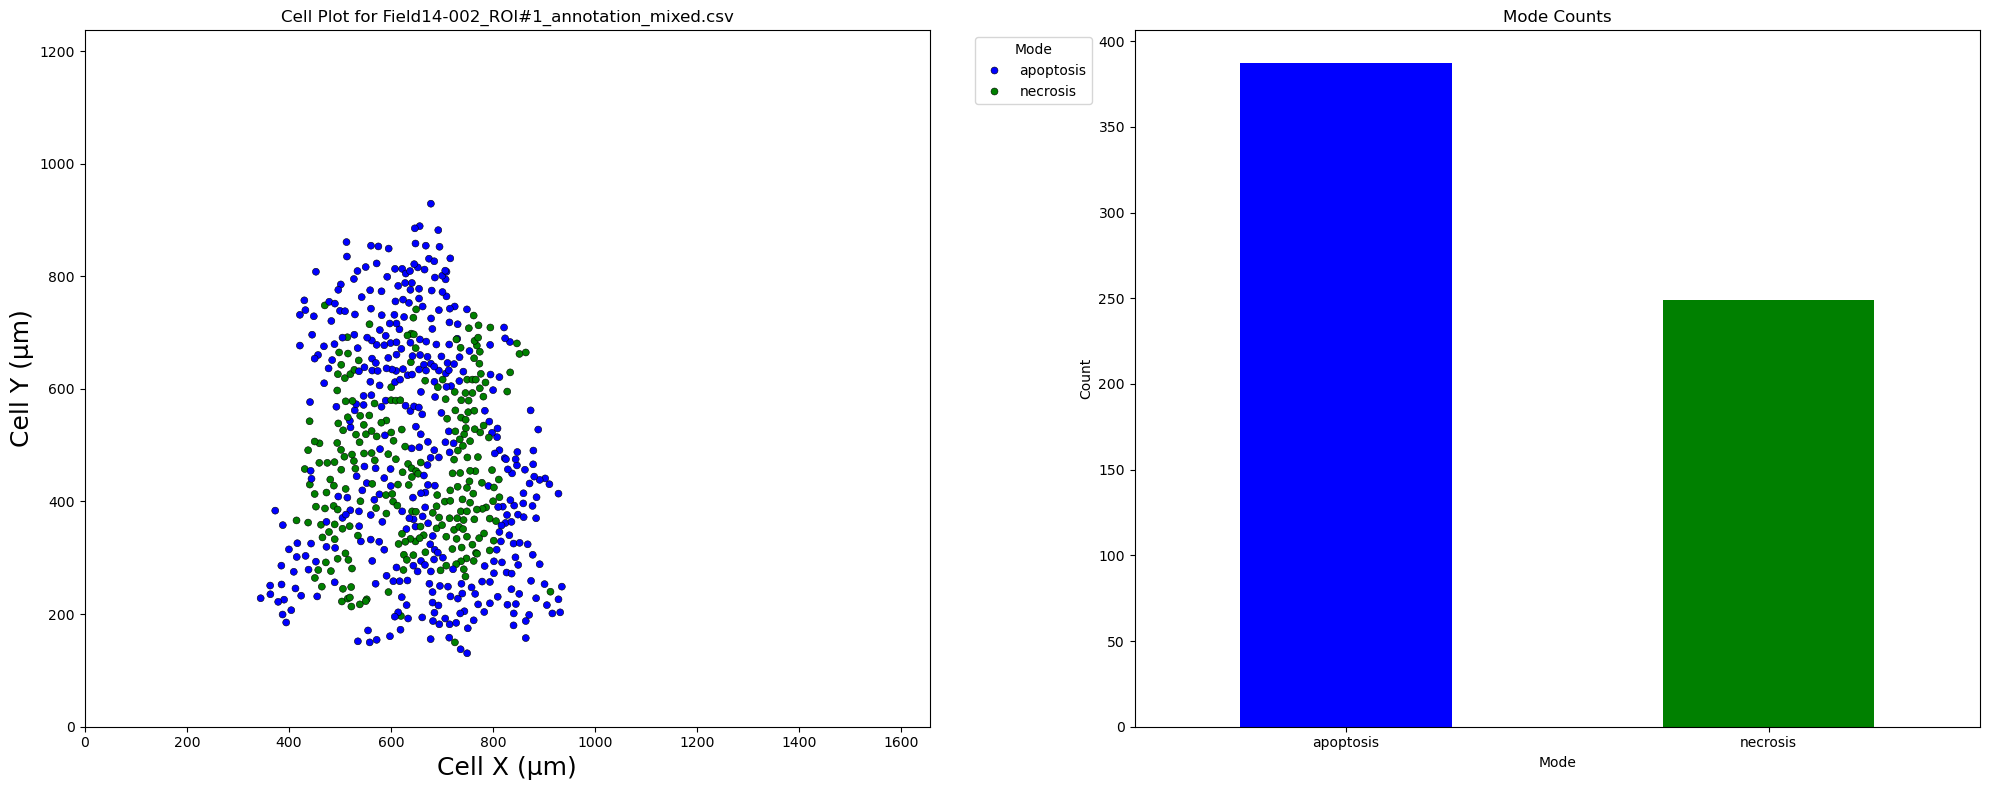

Mode
necrosis     142
apoptosis     47
Name: count, dtype: int64


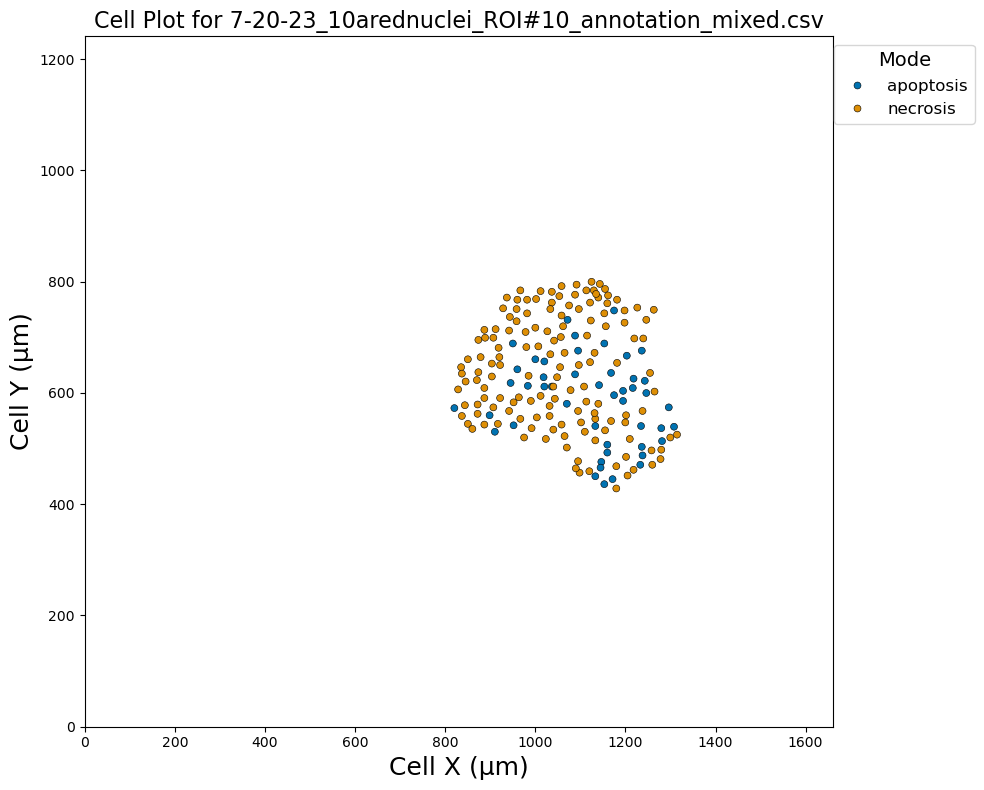

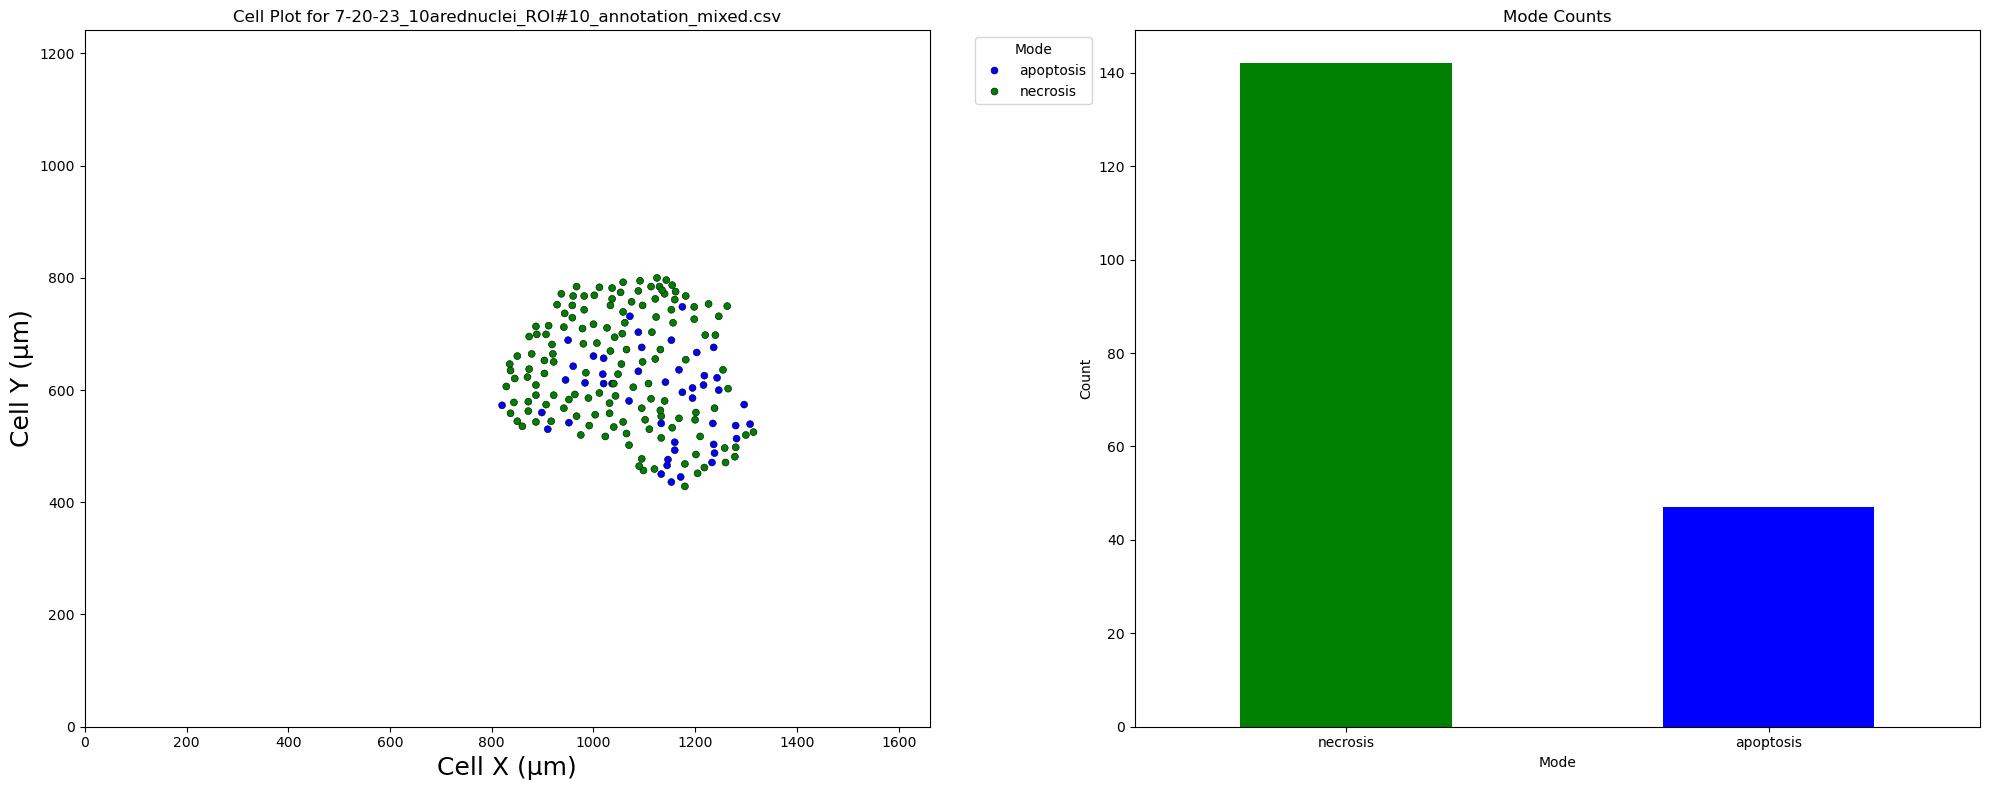

Mode
necrosis     347
apoptosis    248
Name: count, dtype: int64


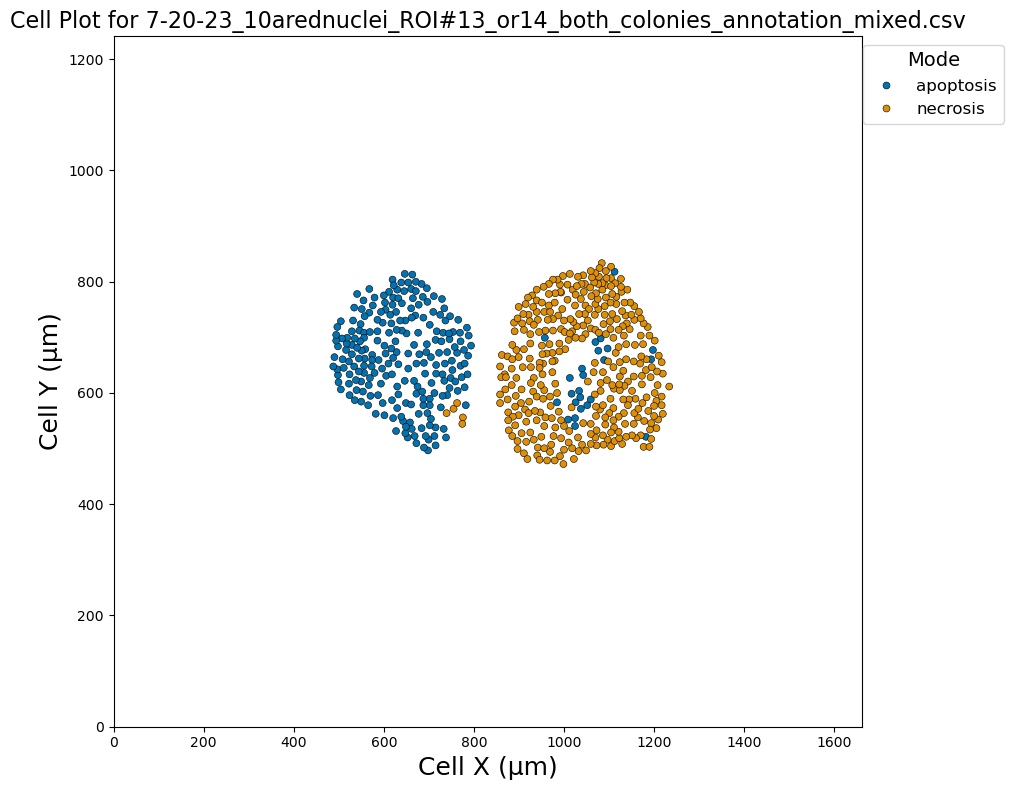

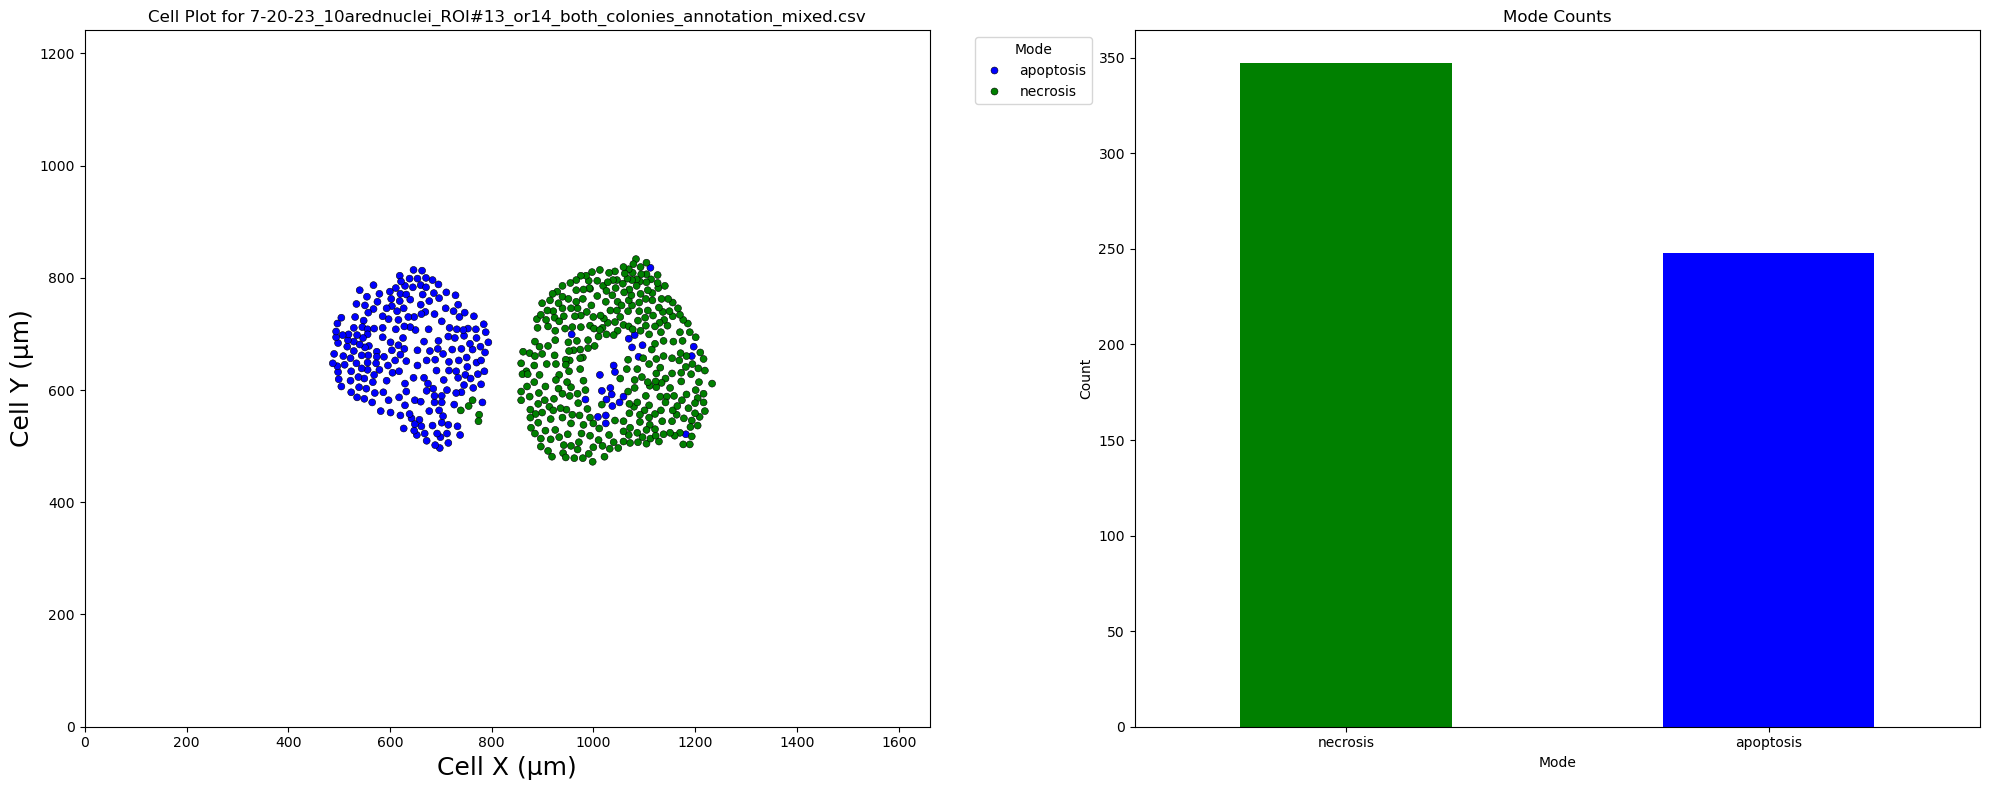

In [3]:
import pandas as pd
import seaborn as sns
import os

import matplotlib.pyplot as plt
custom_palette = {"apoptosis": "blue", "necrosis": "green"}
# Iterate over each file in exp_names
for file_name in exp_names:
    if 'mixed' not in file_name:
        continue  # Skip files that do not contain 'mixed'
    # Get metadata for the current file
    metadata = meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"] == file_name]
    if metadata.empty:
        print(f"Metadata not found for {file_name}. Skipping...")
        continue

    # Extract metadata values
    size_x = int(metadata["SizeX"].values[0])
    size_y = int(metadata["SizeY"].values[0])
    physical_size_x = float(metadata["PhysicalSizeX"].values[0])
    physical_size_y = float(metadata["PhysicalSizeY"].values[0])
    x_limit = size_x * physical_size_x
    y_limit = size_y * physical_size_y

    # Construct the full file path
    file_path = os.path.join(exps_dir_name, file_name)
    if not os.path.exists(file_path):
        print(f"File {file_path} not found. Skipping...")
        continue
    # Count the number of points for each mode
    data = pd.read_csv(file_path)

    # Read the CSV file
    
    legend_labels = {"apoptotic": "apoptosis", "necrotic": "necrosis"}
    data["Mode"] = data["Mode"].replace(legend_labels)
    data = data[data["Mode"].str.lower().isin(["apoptosis", "necrosis", "apoptotic", "necrotic"])]
    mode_counts = data["Mode"].value_counts()
    # Check if required columns exist
    if not {"cell_x", "cell_y", "Mode"}.issubset(data.columns):
        print(f"Required columns not found in {file_name}. Skipping...")
        continue
        # Define a consistent color palette
        
        # Plot the data with a consistent color palette
        sns.set_palette(custom_palette)
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        data=data,
        x="cell_x",
        y="cell_y",
        hue="Mode",
        palette="colorblind",
        edgecolor="black",
        s=25
    )
    plt.title(f"Cell Plot for {file_name}", fontsize=16)
    plt.xlabel("Cell X (μm)", fontsize=18)
    plt.ylabel("Cell Y (μm)", fontsize=18)
    plt.xlim(0, x_limit)
    plt.ylim(0, y_limit)
    plt.legend(title="Mode", loc="upper right", bbox_to_anchor=(1.2, 1), fontsize=12, title_fontsize=14)
    plt.tight_layout()
    # plt.show()
    # Ensure uniform legend label
    # Create subplots
    fig, axs = plt.subplots(1, 2, figsize=(20, 8))
    # Plot the scatterplot on the first subplot
    sns.scatterplot(
        ax=axs[0],
        data=data,
        x="cell_x",
        y="cell_y",
        hue="Mode",
        palette=custom_palette,
        edgecolor="black",
        s=25
    )
    axs[0].set_title(f"Cell Plot for {file_name}")
    axs[0].set_xlabel("Cell X (μm)",  fontsize=18)
    axs[0].set_ylabel("Cell Y (μm)", fontsize=18)
    axs[0].set_xlim(0, x_limit)
    axs[0].set_ylim(0, y_limit)
    axs[0].legend(title="Mode", loc="upper right", bbox_to_anchor=(1.2, 1))

    # Plot the mode counts as a bar plot on the second subplot
    mode_counts.plot(kind='bar', ax=axs[1], color=[custom_palette[mode] for mode in mode_counts.index])
    print(mode_counts)
    axs[1].set_title("Mode Counts")
    axs[1].set_xlabel("Mode")
    axs[1].set_ylabel("Count")
    axs[1].tick_params(axis='x', rotation=0)

    # Adjust layout and show the plots
    plt.tight_layout()
    plt.show()

### with time scale bar, not normalized:

/tmp/ipykernel_3581905/177113599.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])  # Leave space for the colorbar


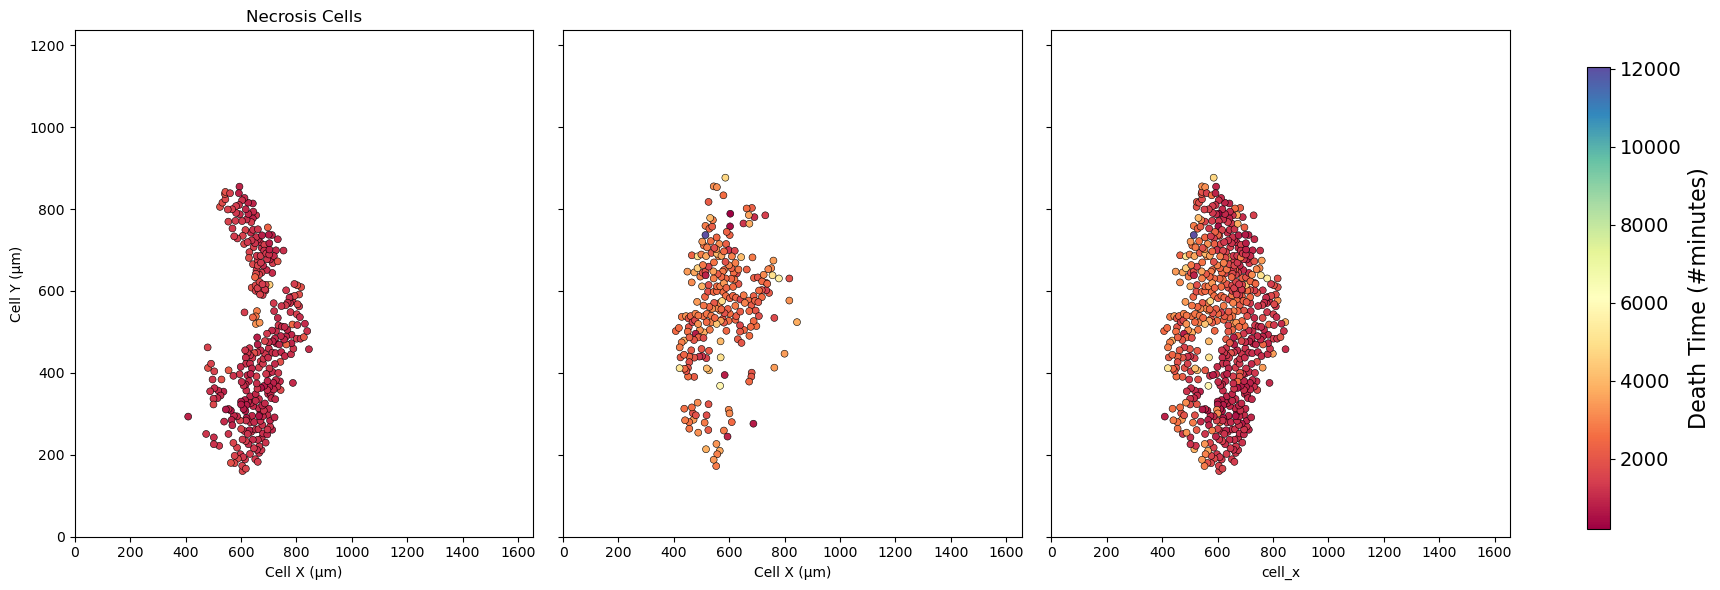

/tmp/ipykernel_3581905/177113599.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])  # Leave space for the colorbar


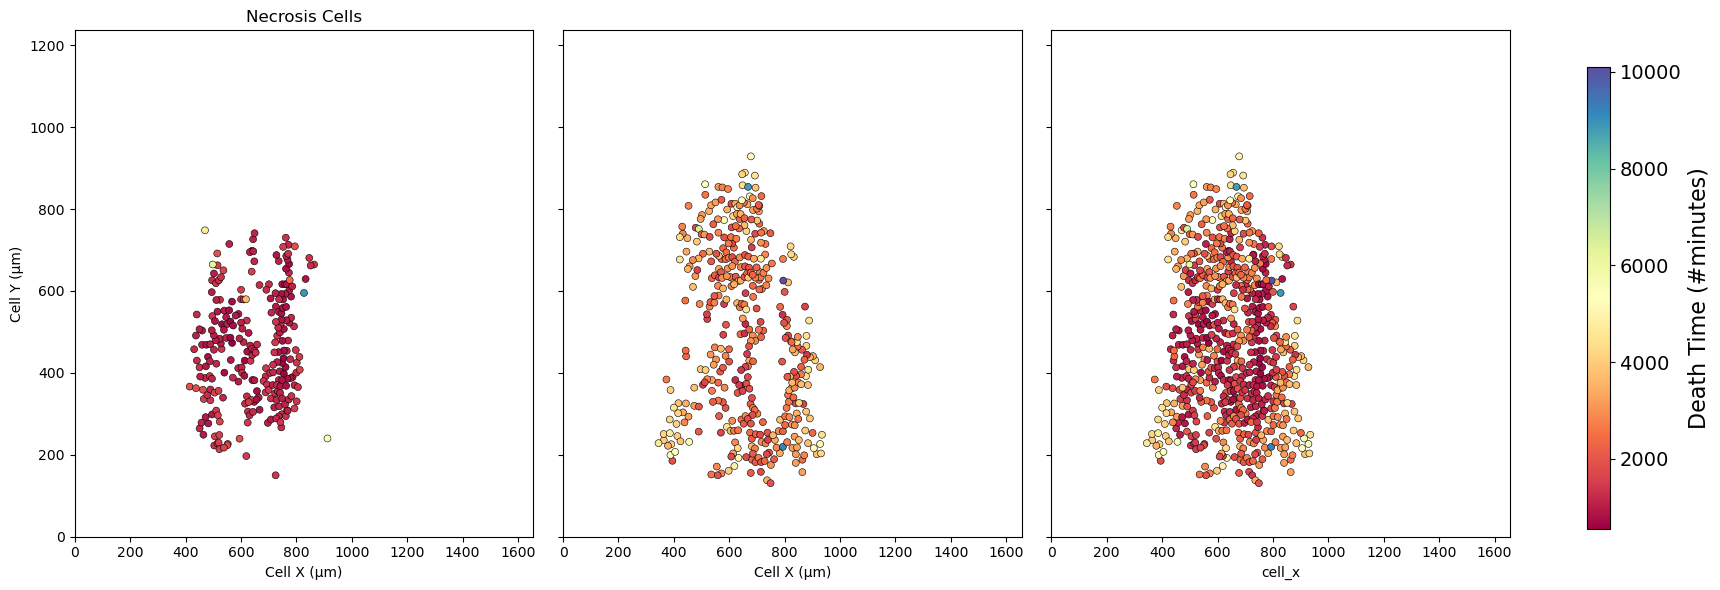

/tmp/ipykernel_3581905/177113599.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])  # Leave space for the colorbar


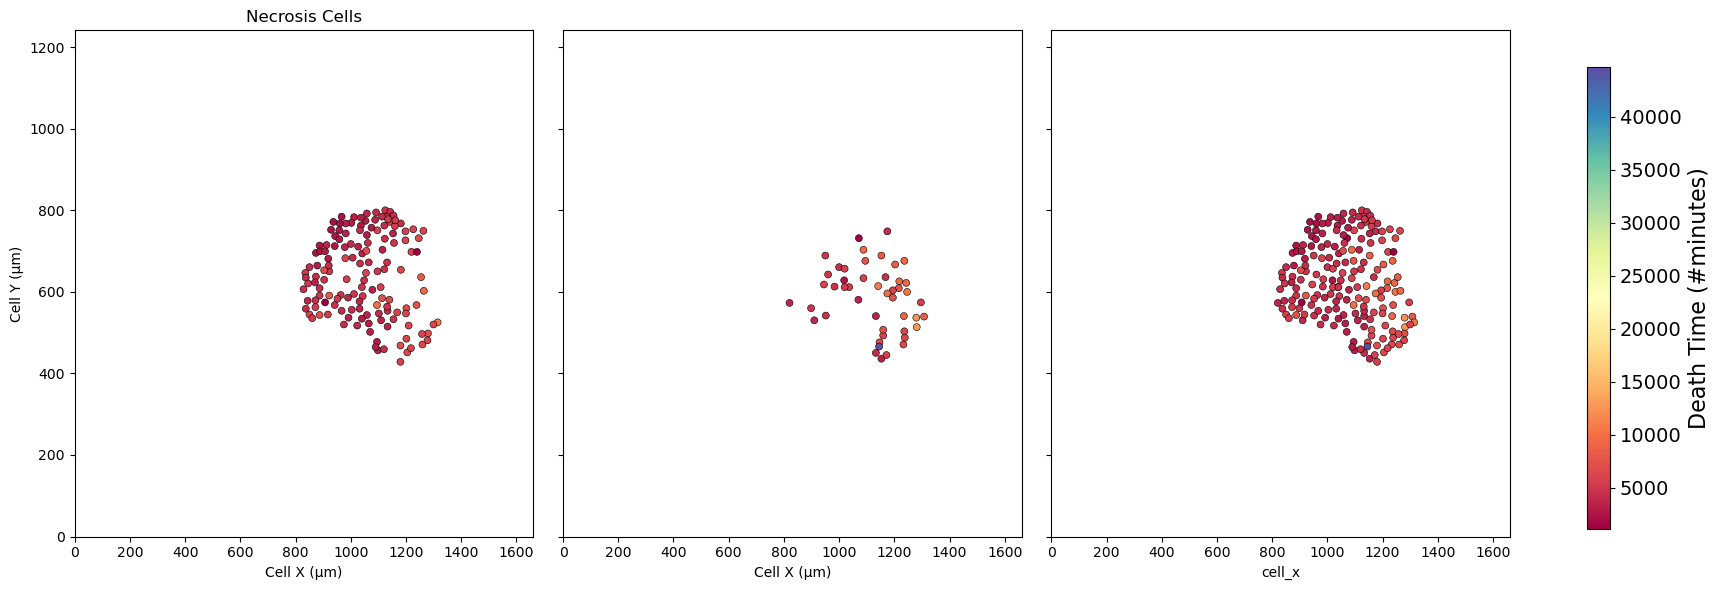

/tmp/ipykernel_3581905/177113599.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])  # Leave space for the colorbar


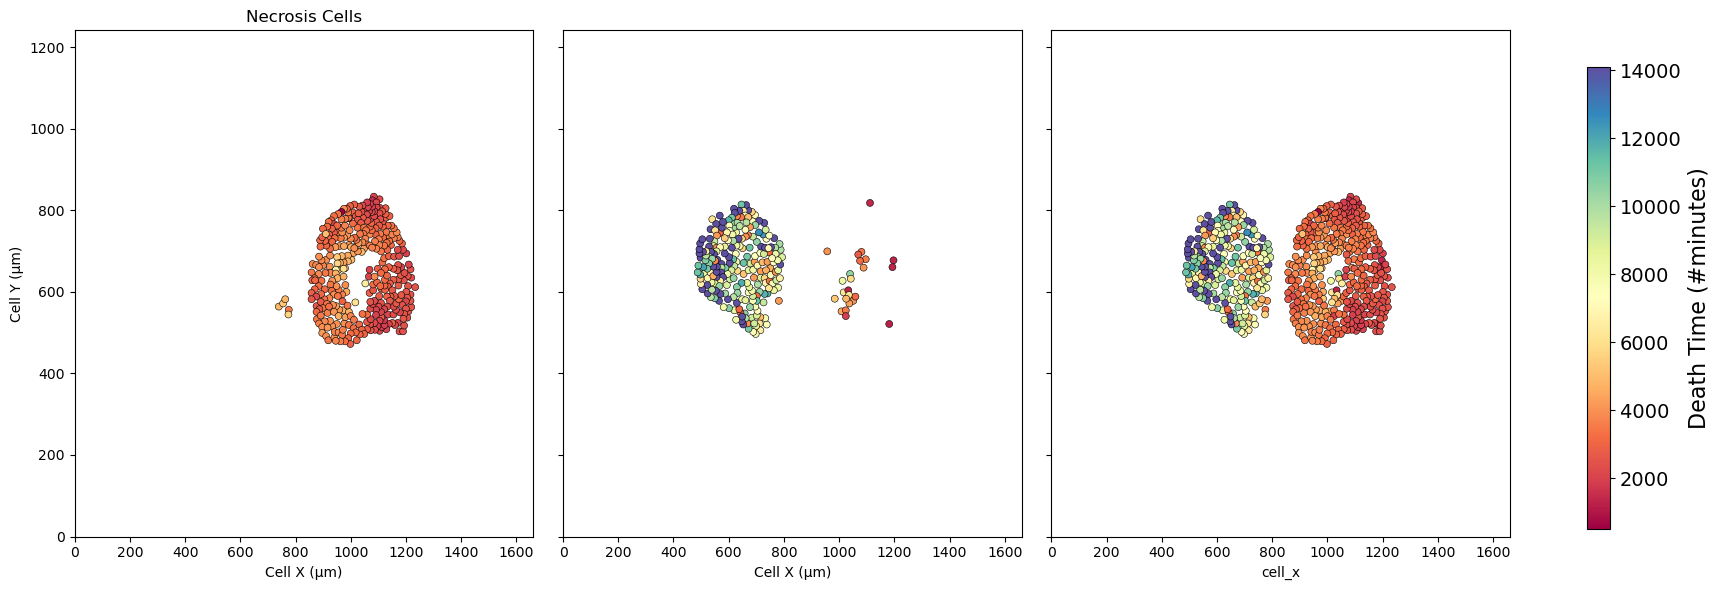

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
for file_name in exp_names:
    if 'mixed' not in file_name:
        continue
    # Get metadata for the current file
    metadata = meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"] == file_name]
    if metadata.empty:
        print(f"Metadata not found for {file_name}. Skipping...")
        continue

    # Extract metadata values

    size_x = int(metadata["SizeX"].values[0])
    size_y = int(metadata["SizeY"].values[0])
    physical_size_x = float(metadata["PhysicalSizeX"].values[0])
    physical_size_y = float(metadata["PhysicalSizeY"].values[0])
    x_limit = size_x * physical_size_x
    y_limit = size_y * physical_size_y

    # Construct the full file path
    file_path = os.path.join(exps_dir_name, file_name)
    if not os.path.exists(file_path):
        print(f"File {file_path} not found. Skipping...")
        continue

    # Read the CSV file
    data = pd.read_csv(file_path)
    data = data[data["Mode"].str.lower().isin(["apoptosis", "necrosis", "apoptotic", "necrotic"])]
    legend_labels = {"apoptotic": "apoptosis", "necrotic": "necrosis"}
    data["Mode"] = data["Mode"].replace(legend_labels)
    if data.empty:
        print(f"No valid data in {file_name}. Skipping...")
        continue

    data["death_time"] = metadata["Time Interval (min)"].values[0] * data["death_time"]
    
    # Create a figure and axes for the subplots
    fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)
    high_value = data["death_time"].max() if not data["death_time"].empty else 0
    # Add a single colorbar outside the plots
    # Normalize the color scale based on the entire dataset's death_time range
    norm = mpl.colors.Normalize(vmin=data["death_time"].min(), vmax=high_value)
    sm = plt.cm.ScalarMappable(cmap="Spectral", norm=norm)
    # Plot 1: Necrosis cells colored by death_time
    scatter1 = sns.scatterplot(
        ax=axs[0],
        data=data[data["Mode"].str.lower() == "necrosis"],
        x="cell_x",
        y="cell_y",
        hue="death_time",
        palette="Spectral",
        edgecolor="black",
        s=25,
        hue_norm=(data["death_time"].min(), high_value)
    )
    axs[0].set_title("Necrosis Cells")
    axs[0].set_xlabel("Cell X (μm)")
    axs[0].set_ylabel("Cell Y (μm)")
    # axs[0].legend(title="Death Time", loc="upper right", bbox_to_anchor=(1.2, 1))

    # Plot 2: Apoptosis cells colored by death_time
    scatter2 = sns.scatterplot(
        ax=axs[1],
        data=data[data["Mode"].str.lower() == "apoptosis"],
        x="cell_x",
        y="cell_y",
        hue="death_time",
        palette="Spectral",
        edgecolor="black",
        s=25,
        hue_norm=(data["death_time"].min(), high_value)
    )
    axs[1].set_xlabel("Cell X (μm)")
    axs[1].set_ylabel("")
    # axs[1].legend(title="Death Time", loc="upper right", bbox_to_anchor=(1.2, 1))

    # Plot 3: Both modes colored by death_time

    scatter3 = sns.scatterplot(
        ax=axs[2],
        data=data,
        x="cell_x",
        y="cell_y",
        hue="death_time",
        palette="Spectral",
        edgecolor="black",
        s=25,
        hue_norm=(data["death_time"].min(), high_value)
    )
    axs[2].set_ylabel("")
    # axs[2].legend(title="Death Time", loc="upper right", bbox_to_anchor=(1.2, 1))

    # Set the same x and y limits for all plots
    for ax in axs:
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
        ax.set_xlim(0, x_limit)
        ax.set_ylim(0, y_limit)


    # Apply the same color normalization to all subplots
    scatter1.norm = norm
    scatter2.norm = norm
    scatter3.norm = norm
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axs, orientation='vertical', fraction=0.02, pad=0.1)
    cbar.ax.tick_params(labelsize=14)  # Make font size of colorbar labels bigger
    cbar.set_label("Death Time (#minutes)", fontsize=16)  # Set label with bigger font size

    # Adjust layout
    plt.tight_layout(rect=[0, 0, 0.85, 1])  # Leave space for the colorbar
    plt.show()


### no time of death

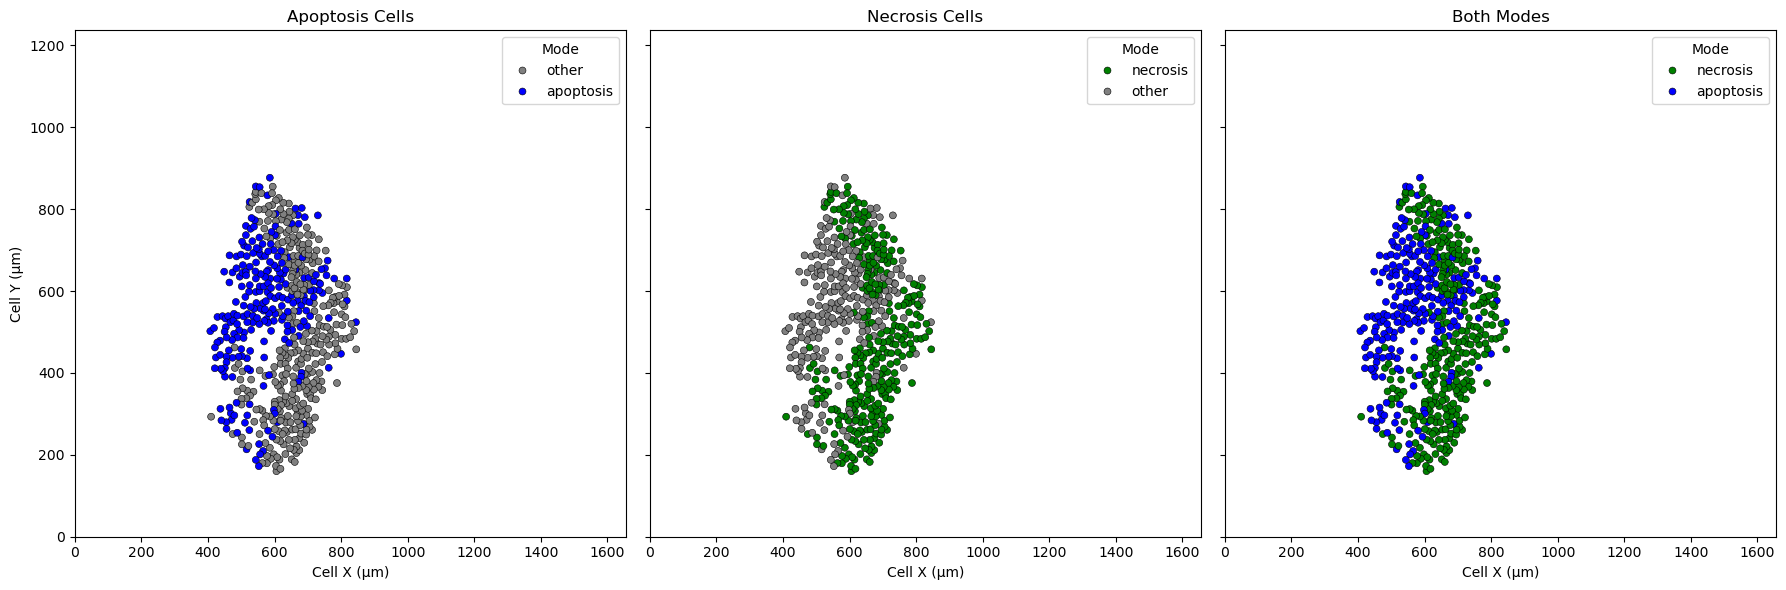

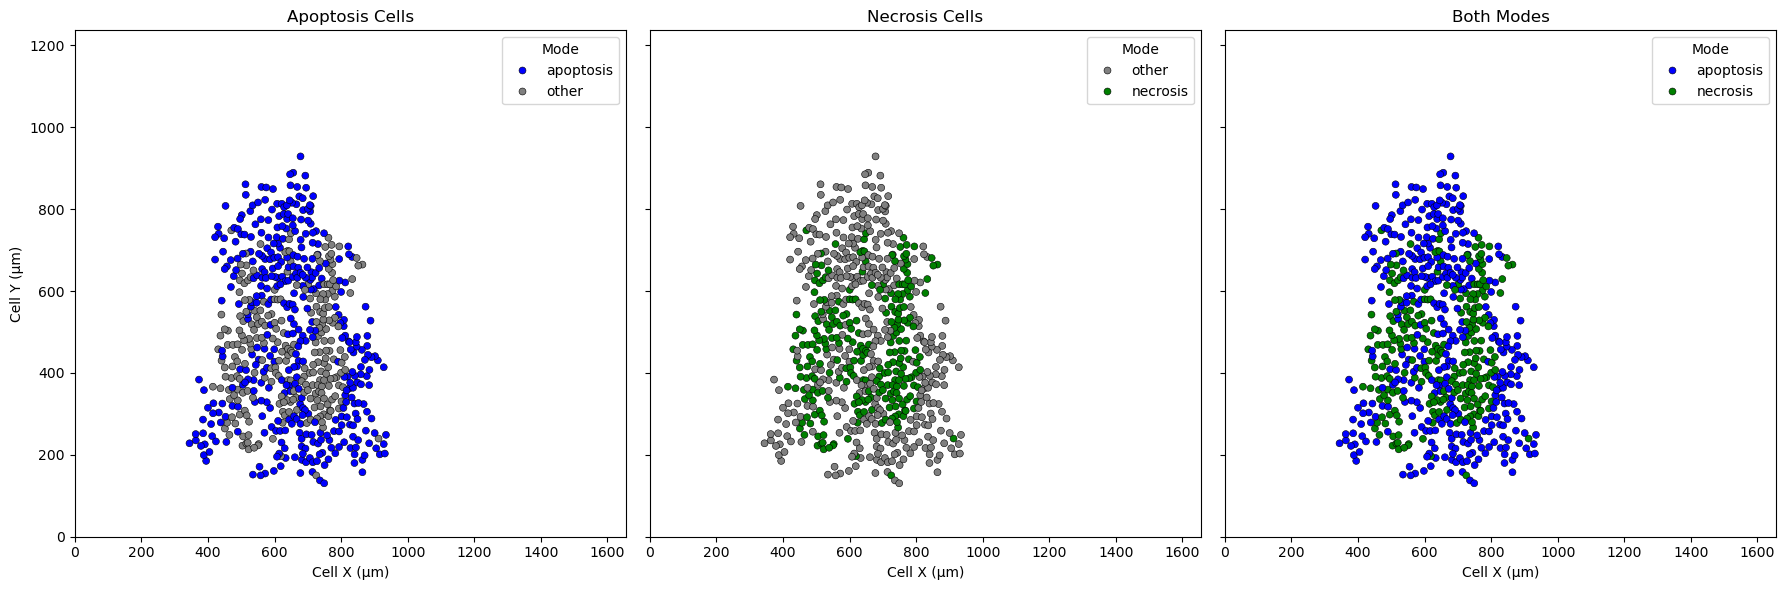

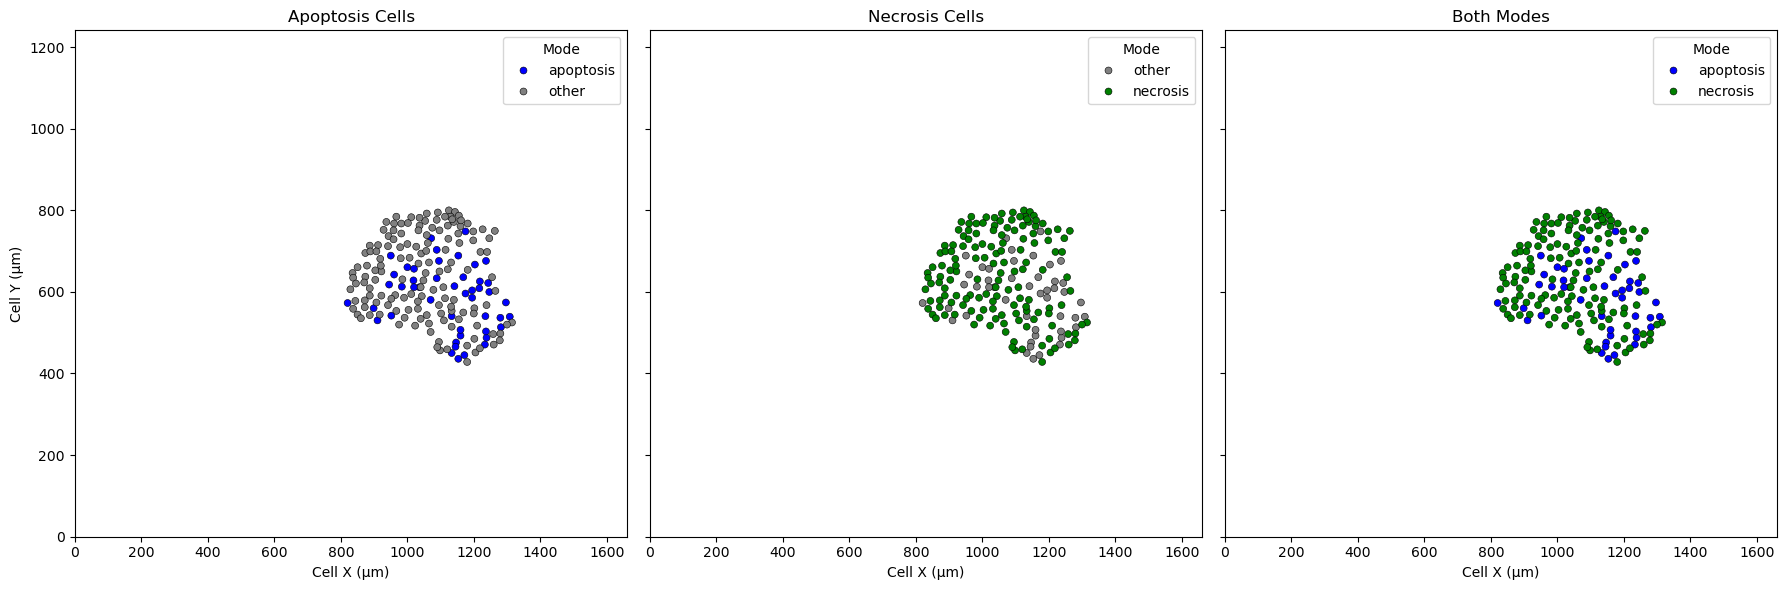

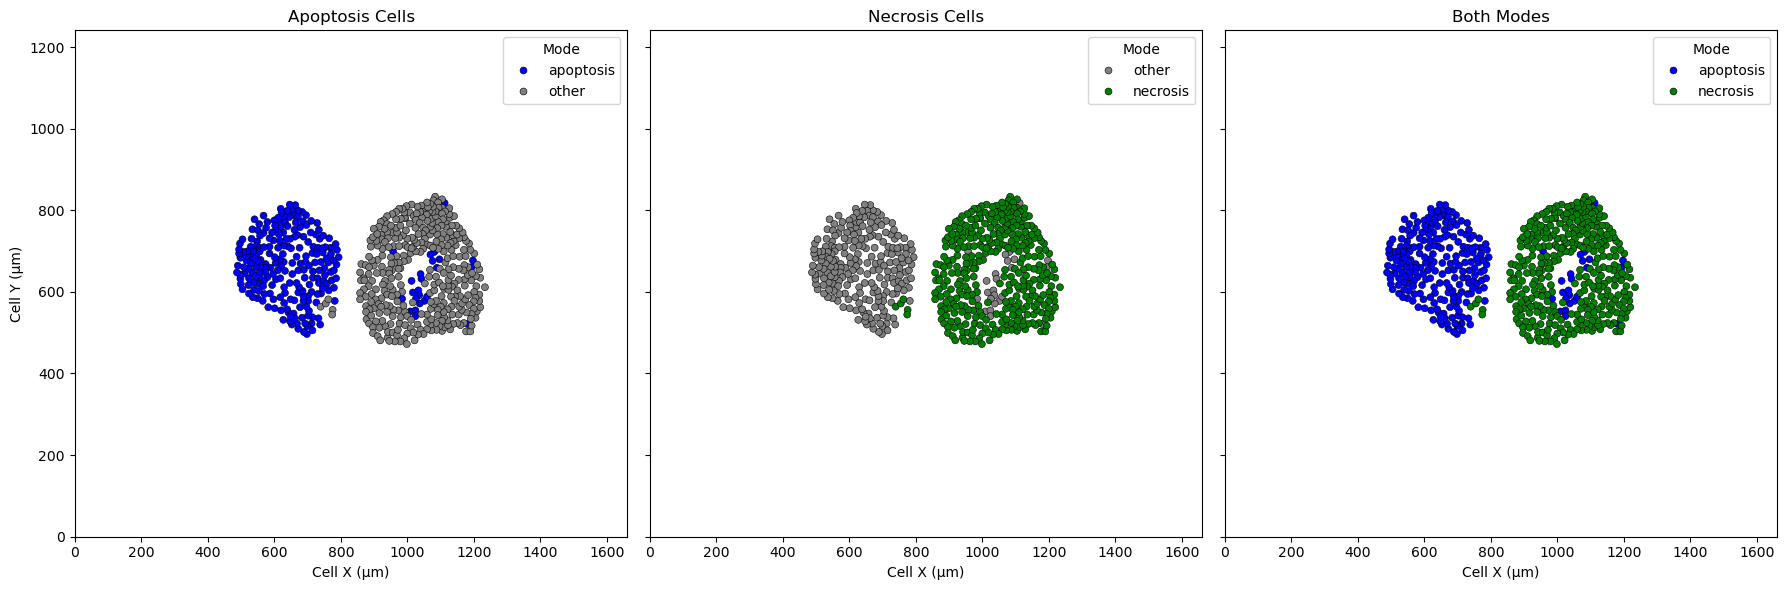

In [19]:
import pandas as pd
import seaborn as sns
import os

import matplotlib.pyplot as plt
custom_palette = {"apoptosis": "blue", "necrosis": "green"}
# Iterate over each file in exp_names
for file_name in exp_names:
    if 'mixed' not in file_name:
        continue  # Skip files that do not contain 'mixed'
    # Get metadata for the current file
    metadata = meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"] == file_name]
    if metadata.empty:
        print(f"Metadata not found for {file_name}. Skipping...")
        continue
    size_x = int(metadata["SizeX"].values[0])
    size_y = int(metadata["SizeY"].values[0])
    physical_size_x = float(metadata["PhysicalSizeX"].values[0])
    physical_size_y = float(metadata["PhysicalSizeY"].values[0])
    x_limit = size_x * physical_size_x
    y_limit = size_y * physical_size_y

    # Construct the full file path
    file_path = os.path.join(exps_dir_name, file_name)
    if not os.path.exists(file_path):
        print(f"File {file_path} not found. Skipping...")
        continue

    # Read the CSV file
    data = pd.read_csv(file_path)
    data = data[data["Mode"].str.lower().isin(["apoptosis", "necrosis", "apoptotic", "necrotic"])]
    legend_labels = {"apoptotic": "apoptosis", "necrotic": "necrosis"}
    data["Mode"] = data["Mode"].replace(legend_labels)
    if data.empty:
        print(f"No valid data in {file_name}. Skipping...")
        continue

    # data["death_time"] = metadata["Time Interval (min)"].values[0] * data["death_time"]
    # Create a figure and axes for the subplots
    fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

    # Plot 1: Apoptosis cells in blue, others in grey
    sns.scatterplot(
        ax=axs[0],
        data=data,
        x="cell_x",
        y="cell_y",
        hue=data["Mode"].apply(lambda mode: "apoptosis" if mode == "apoptosis" else "other"),
        palette={"apoptosis": custom_palette["apoptosis"], "other": "grey"},
        edgecolor="black",
        s=25
    )
    axs[0].set_title("Apoptosis Cells")
    axs[0].set_xlabel("Cell X (μm)")
    axs[0].set_ylabel("Cell Y (μm)")
    axs[0].legend(title="Mode", loc="upper right")

    # Plot 2: Necrosis cells in green, others in grey
    sns.scatterplot(
        ax=axs[1],
        data=data,
        x="cell_x",
        y="cell_y",
        hue=data["Mode"].apply(lambda mode: "necrosis" if mode == "necrosis" else "other"),
        palette={"necrosis": custom_palette["necrosis"], "other": "grey"},
        edgecolor="black",
        s=25
    )
    axs[1].set_title("Necrosis Cells")
    axs[1].set_xlabel("Cell X (μm)")
    axs[1].set_ylabel("")

    # Plot 3: Both modes with their respective colors
    sns.scatterplot(
        ax=axs[2],
        data=data,
        x="cell_x",
        y="cell_y",
        hue="Mode",
        palette=custom_palette,
        edgecolor="black",
        s=25
    )
    axs[2].set_title("Both Modes")
    axs[2].set_xlabel("Cell X (μm)")
    axs[2].set_ylabel("")

    # Set the same x and y limits for all plots
    for ax in axs:
        ax.set_xlim(0, x_limit)
        ax.set_ylim(0, y_limit)

    # Adjust layout and show the plots
    plt.tight_layout()
    plt.show()
    

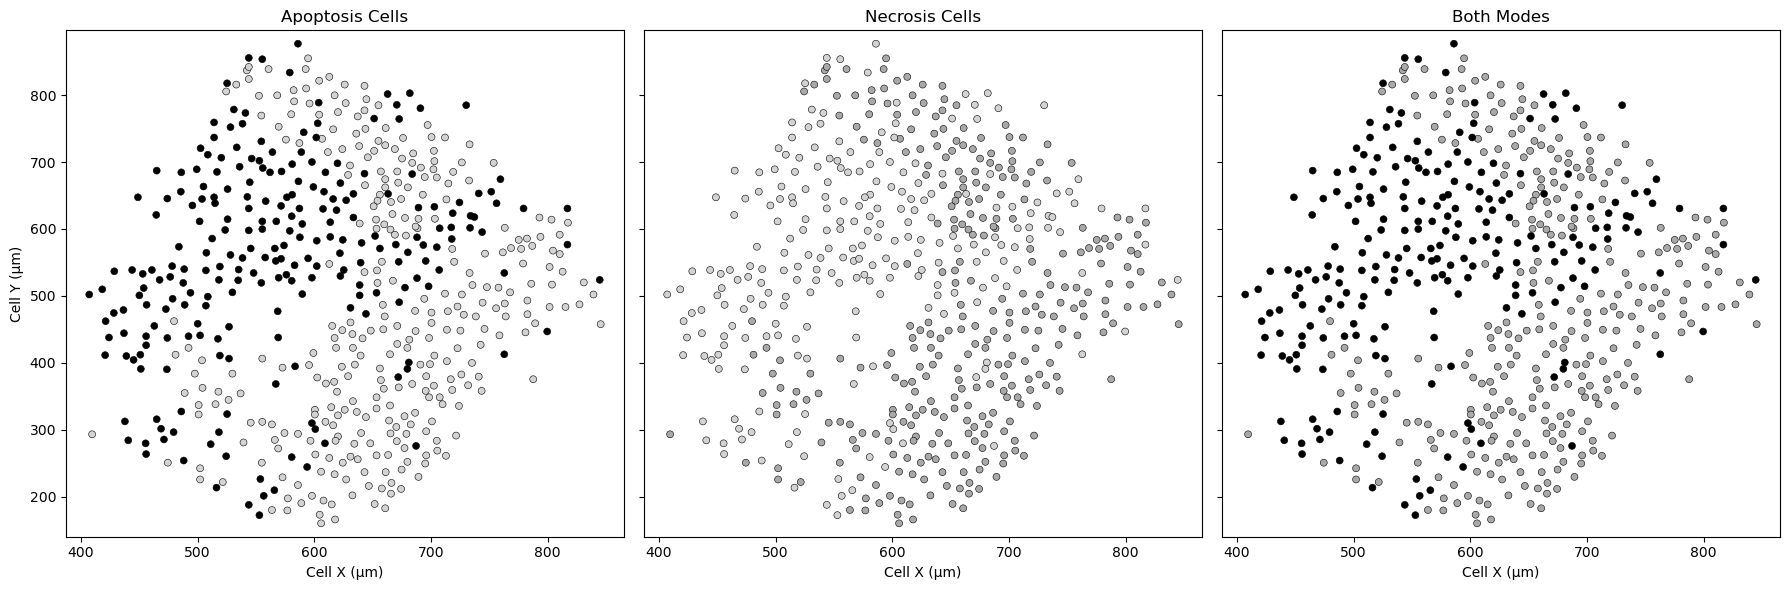

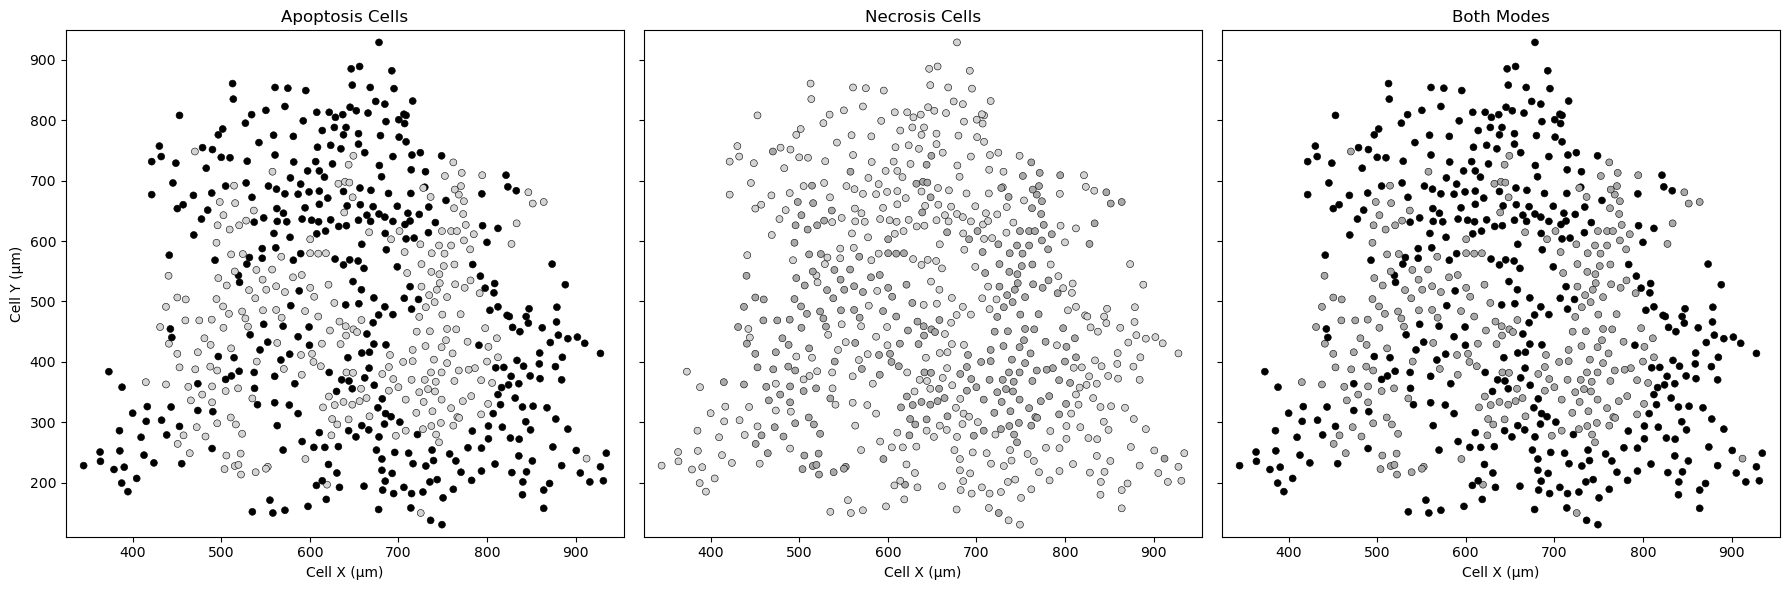

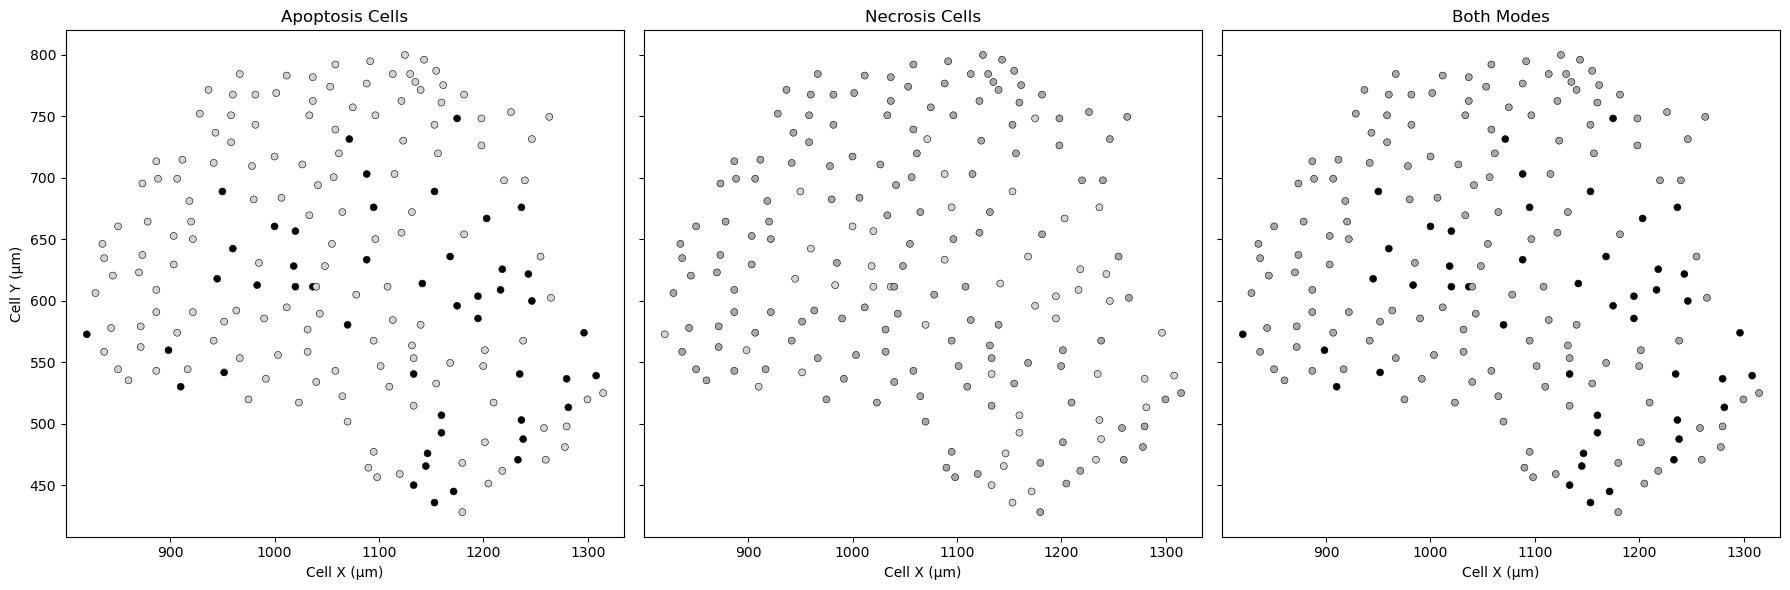

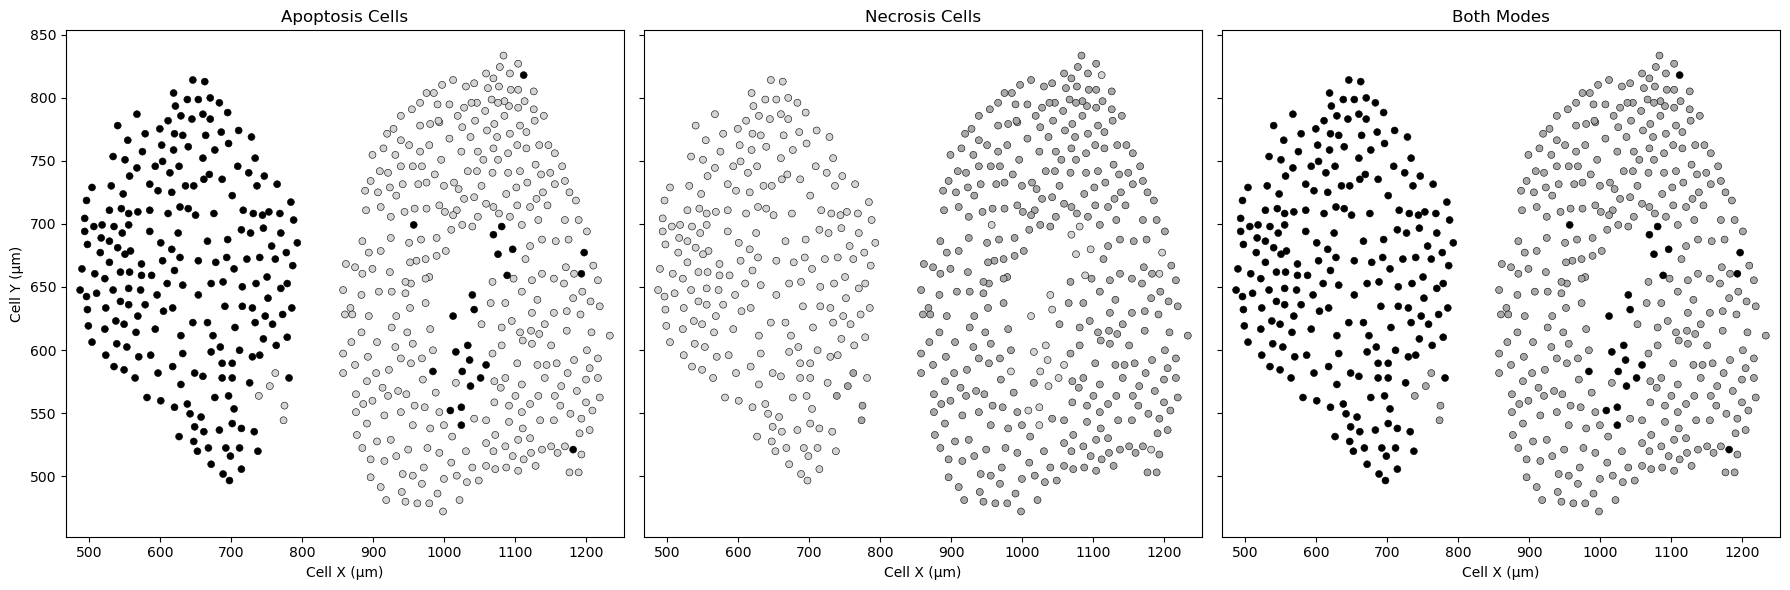

In [5]:
import pandas as pd
import seaborn as sns
import os
custom_palette = {"apoptosis": "black", "necrosis": "darkgray", "other": "lightgray"}



import matplotlib.pyplot as plt
# custom_palette = {"apoptosis": "blue", "necrosis": "green"}
# Iterate over each file in exp_names
for file_name in exp_names:
    if 'mixed' not in file_name:
        continue  # Skip files that do not contain 'mixed'
    # Get metadata for the current file
    metadata = meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"] == file_name]
    if metadata.empty:
        print(f"Metadata not found for {file_name}. Skipping...")
        continue
    size_x = int(metadata["SizeX"].values[0])
    size_y = int(metadata["SizeY"].values[0])
    physical_size_x = float(metadata["PhysicalSizeX"].values[0])
    physical_size_y = float(metadata["PhysicalSizeY"].values[0])
    

    # Construct the full file path
    file_path = os.path.join(exps_dir_name, file_name)
    if not os.path.exists(file_path):
        print(f"File {file_path} not found. Skipping...")
        continue

    # Read the CSV file
    data = pd.read_csv(file_path)
    data = data[data["Mode"].str.lower().isin(["apoptosis", "necrosis", "apoptotic", "necrotic"])]
    legend_labels = {"apoptotic": "apoptosis", "necrotic": "necrosis"}
    data["Mode"] = data["Mode"].replace(legend_labels)
    if data.empty:
        print(f"No valid data in {file_name}. Skipping...")
        continue
    x_limit = (data["cell_x"].min()-20, data["cell_x"].max()+20)
    y_limit = (data["cell_y"].min()-20, data["cell_y"].max()+20)
    # data["death_time"] = metadata["Time Interval (min)"].values[0] * data["death_time"]
    # Create a figure and axes for the subplots
    fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

    # Plot 1: Apoptosis cells in black, others in light gray
    sns.scatterplot(
        ax=axs[0],
        data=data,
        x="cell_x",
        y="cell_y",
        hue=data["Mode"].apply(lambda mode: "apoptosis" if mode == "apoptosis" else "other"),
        palette={"apoptosis": custom_palette["apoptosis"], "other": custom_palette["other"]},
        edgecolor="black",
        s=25
    )
    axs[0].set_title("Apoptosis Cells")
    axs[0].set_xlabel("Cell X (μm)")
    axs[0].set_ylabel("Cell Y (μm)")
    axs[0].legend(title="Mode", loc="upper right")

    # Plot 2: Necrosis cells in dark gray, others in light gray
    sns.scatterplot(
        ax=axs[1],
        data=data,
        x="cell_x",
        y="cell_y",
        hue=data["Mode"].apply(lambda mode: "necrosis" if mode == "necrosis" else "other"),
        palette={"necrosis": custom_palette["necrosis"], "other": custom_palette["other"]},
        edgecolor="black",
        s=25
    )
    axs[1].set_title("Necrosis Cells")
    axs[1].set_xlabel("Cell X (μm)")
    axs[1].set_ylabel("")

    # Plot 3: Both modes with their respective shades
    sns.scatterplot(
        ax=axs[2],
        data=data,
        x="cell_x",
        y="cell_y",
        hue="Mode",
        palette=custom_palette,
        edgecolor="black",
        s=25
    )
    axs[2].set_title("Both Modes")
    axs[2].set_xlabel("Cell X (μm)")
    axs[2].set_ylabel("")

    # Set the same x and y limits for all plots
    for ax in axs:
        ax.get_legend().remove()
        ax.set_xlim(x_limit)
        ax.set_ylim(y_limit)

    # Adjust layout and show the plots
    
    plt.tight_layout()
    plt.savefig(f"/home/esraan/CellDeathSpreading/results/{file_name}_crop.svg", format="svg")
    plt.show()
    

### Subplots for both deaths (BW)

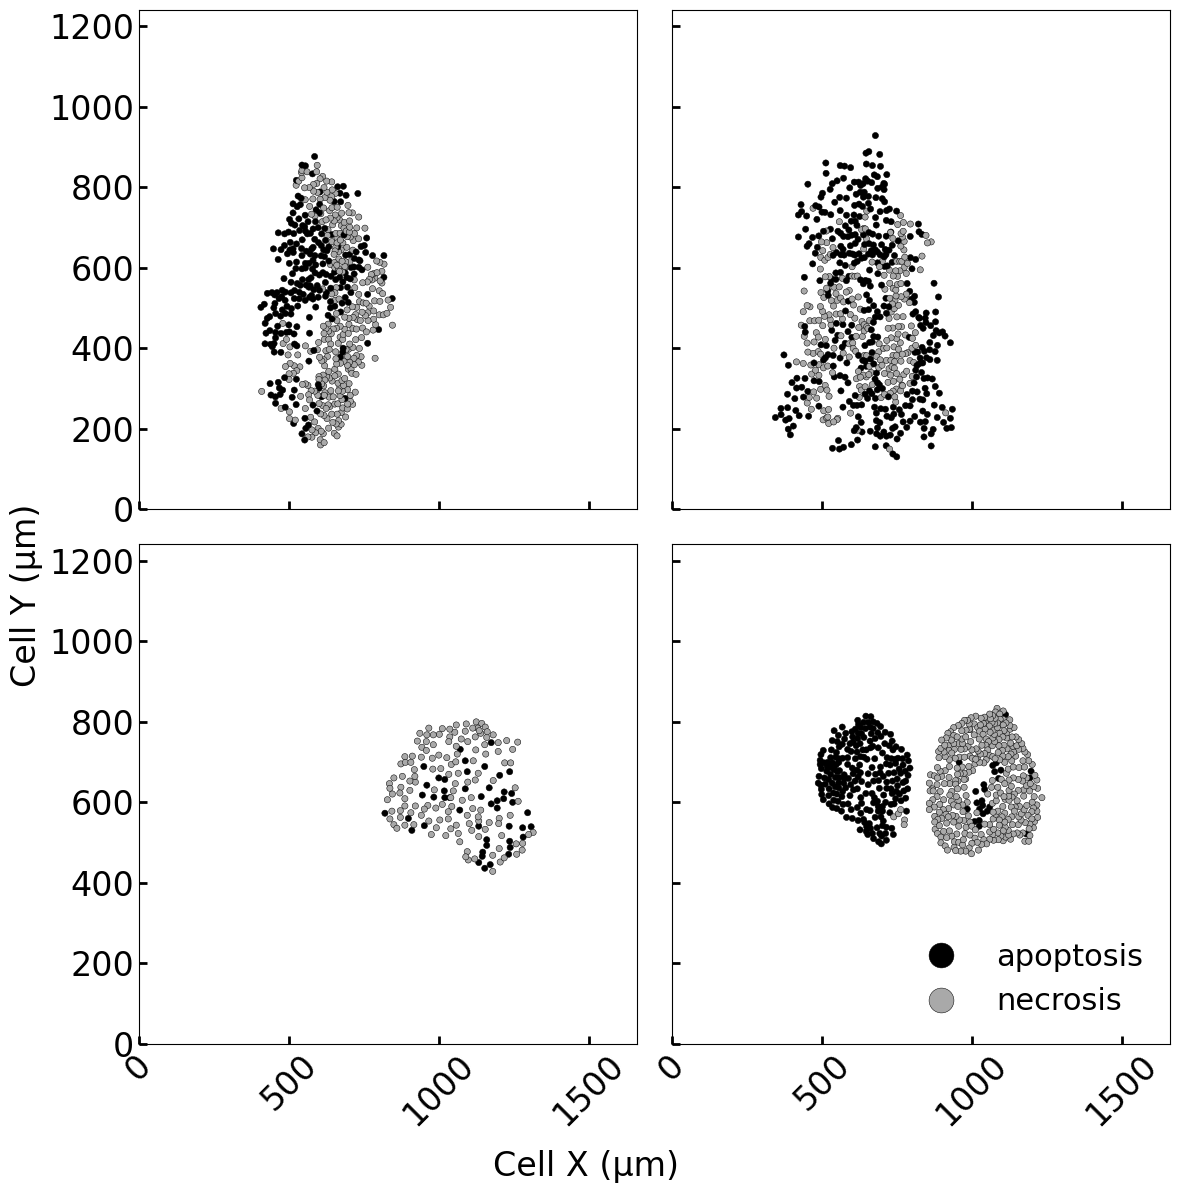

In [55]:
import pandas as pd
import seaborn as sns
import os
import matplotlib.ticker as ticker
custom_palette = {"apoptosis": "black", "necrosis": "darkgray", "other": "lightgray"}



# Create a 2x2 subplot grid
fig, axs = plt.subplots(2, 2, figsize=(12, 12), sharex=True, sharey=True)

# Flatten the axs array for easier indexing
axs = axs.flatten()

# Initialize a counter for subplot index
subplot_idx = 0

# Iterate over each file in exp_names
for file_name in exp_names:
    if 'mixed' not in file_name:
        continue  # Skip files that do not contain 'mixed'
    
    # Get metadata for the current file
    metadata = meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"] == file_name]
    if metadata.empty:
        print(f"Metadata not found for {file_name}. Skipping...")
        continue
    
    size_x = int(metadata["SizeX"].values[0])
    size_y = int(metadata["SizeY"].values[0])
    physical_size_x = float(metadata["PhysicalSizeX"].values[0])
    physical_size_y = float(metadata["PhysicalSizeY"].values[0])
    
    # Construct the full file path
    file_path = os.path.join(exps_dir_name, file_name)
    if not os.path.exists(file_path):
        print(f"File {file_path} not found. Skipping...")
        continue

    # Read the CSV file
    data = pd.read_csv(file_path)
    data = data[data["Mode"].str.lower().isin(["apoptosis", "necrosis", "apoptotic", "necrotic"])]
    legend_labels = {"apoptotic": "apoptosis", "necrotic": "necrosis"}
    data["Mode"] = data["Mode"].replace(legend_labels)
    if data.empty:
        print(f"No valid data in {file_name}. Skipping...")
        continue
    
    x_limit = (0, physical_size_x * size_x)
    y_limit = (0, physical_size_y * size_y)

    # Plot combined modes with their respective shades
    sns.scatterplot(
        ax=axs[subplot_idx],
        data=data,
        x="cell_x",
        y="cell_y",
        hue="Mode",
        palette=custom_palette,
        edgecolor="black",
        s=20
    )
    # axs[subplot_idx].set_title(f"File: {file_name}")
    axs[subplot_idx].set_xlabel("", fontsize=24)
    axs[subplot_idx].set_ylabel("", fontsize=24)
    axs[subplot_idx].set_xlim(x_limit)
    axs[subplot_idx].set_ylim(y_limit)
    if subplot_idx == 3:
        axs[subplot_idx].legend(loc="lower right", fontsize=24, scatterpoints=2, prop={'size':22}, markerscale=4, frameon = False)  # Adjust font size and scatterpoints
    else: 
        axs[subplot_idx].get_legend().remove()
    axs[subplot_idx].tick_params(axis='both', which='major', labelsize=24, length=6, width=2)  # Major ticks
    axs[subplot_idx].tick_params(axis='both', which='minor', labelsize=24, length=4, width=1)  # Minor ticks
    
    # Add internal ticks
    axs[subplot_idx].tick_params(axis='both', direction='in', top=False, right=False)
    
    # Format tick numbers (optional, e.g., to remove scientific notation or format as integers)
    axs[subplot_idx].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x)}'))
    axs[subplot_idx].yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{int(y)}'))
    axs[subplot_idx].set_facecolor('none')
    for label in axs[subplot_idx].get_xticklabels():
        label.set_rotation(45)
    # Increment subplot index
    subplot_idx += 1

    # Stop if all subplots are filled
    if subplot_idx >= len(axs):
        break
# Add a single x_label and y_label for the entire figure
fig.supxlabel("Cell X (μm)", fontsize=24)
fig.supylabel("Cell Y (μm)", fontsize=24)
# Adjust layout and show the plots
plt.tight_layout()
plt.savefig(f"/home/esraan/CellDeathSpreading/results/combined_plots2406251658.svg", format="svg",facecolor='none')
plt.show()

    

### colorfull colonies: no x/y axis with scale bar

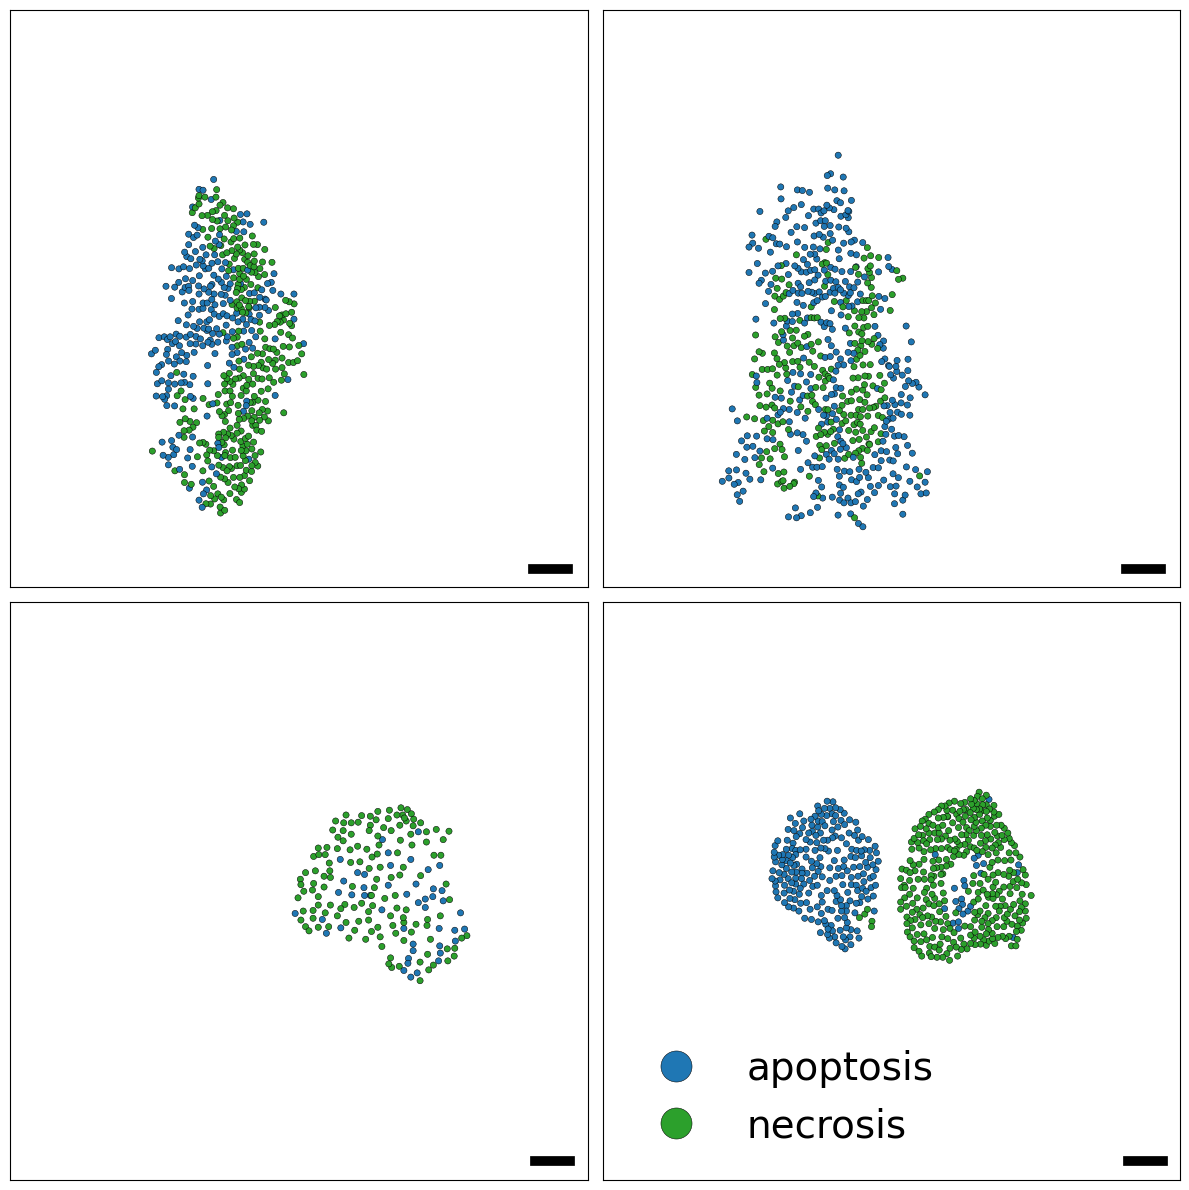

In [4]:
import pandas as pd
import seaborn as sns
import os
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

custom_palette = {"apoptosis": "#1f77b4", "necrosis": "#2ca02c", "other": "lightgray"}

# Create a 2x2 subplot grid
fig, axs = plt.subplots(2, 2, figsize=(12, 12), sharex=True, sharey=True)

# Flatten the axs array for easier indexing
axs = axs.flatten()

# Initialize a counter for subplot index
subplot_idx = 0

# Iterate over each file in exp_names
for file_name in exp_names:
    if 'mixed' not in file_name:
        continue  # Skip files that do not contain 'mixed'
    
    # Get metadata for the current file
    metadata = meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"] == file_name]
    if metadata.empty:
        print(f"Metadata not found for {file_name}. Skipping...")
        continue
    
    size_x = int(metadata["SizeX"].values[0])
    size_y = int(metadata["SizeY"].values[0])
    physical_size_x = float(metadata["PhysicalSizeX"].values[0])
    physical_size_y = float(metadata["PhysicalSizeY"].values[0])
    
    # Construct the full file path
    file_path = os.path.join(exps_dir_name, file_name)
    if not os.path.exists(file_path):
        print(f"File {file_path} not found. Skipping...")
        continue

    # Read the CSV file
    data = pd.read_csv(file_path)
    data = data[data["Mode"].str.lower().isin(["apoptosis", "necrosis", "apoptotic", "necrotic"])]
    legend_labels = {"apoptotic": "apoptosis", "necrotic": "necrosis"}
    data["Mode"] = data["Mode"].replace(legend_labels)
    if data.empty:
        print(f"No valid data in {file_name}. Skipping...")
        continue
    
    x_limit = (0, physical_size_x * size_x)
    y_limit = (0, physical_size_y * size_y)

    # Plot combined modes with their respective shades
    sns.scatterplot(
        ax=axs[subplot_idx],
        data=data,
        x="cell_x",
        y="cell_y",
        hue="Mode",
        palette=custom_palette,
        edgecolor="black",
        s=20,
    )
    axs[subplot_idx].set_xlim(x_limit)
    axs[subplot_idx].set_ylim(y_limit)

    # Remove x and y ticks and labels
    axs[subplot_idx].tick_params(axis='both', which='both', length=0, labelbottom=False, labelleft=False)
    # axs[subplot_idx].set_title(f"File: {file_name}")
    axs[subplot_idx].set_xlabel("", fontsize=24)
    axs[subplot_idx].set_ylabel("", fontsize=24)
    # Add a scale bar at the lower-right corner
    scale_bar_length = 100  # Length of the scale bar
    scale_bar_x = x_limit[1] - scale_bar_length - 50  # Position of the scale bar (x-coordinate)
    scale_bar_y = y_limit[0] + 40  # Position of the scale bar (y-coordinate)
    axs[subplot_idx].add_line(Line2D([scale_bar_x, scale_bar_x + scale_bar_length], 
                                     [scale_bar_y, scale_bar_y], 
                                     color="black", linewidth=7))
    axs[subplot_idx].set_facecolor('none')
    # Remove legend for all but the last subplot
    if subplot_idx == 3:
        axs[subplot_idx].legend(loc="lower left", fontsize=28, scatterpoints=8, markerscale=5, frameon=False)
    else:
        axs[subplot_idx].get_legend().remove()

    # Increment subplot index
    subplot_idx += 1

    # Stop if all subplots are filled
    if subplot_idx >= len(axs):
        break

# Adjust layout and show the plots
plt.tight_layout()
plt.savefig(f"/home/esraan/CellDeathSpreading/results/combined_plots_with_scalebar.svg", format="svg", facecolor='none')
plt.show()

### no tightlayout

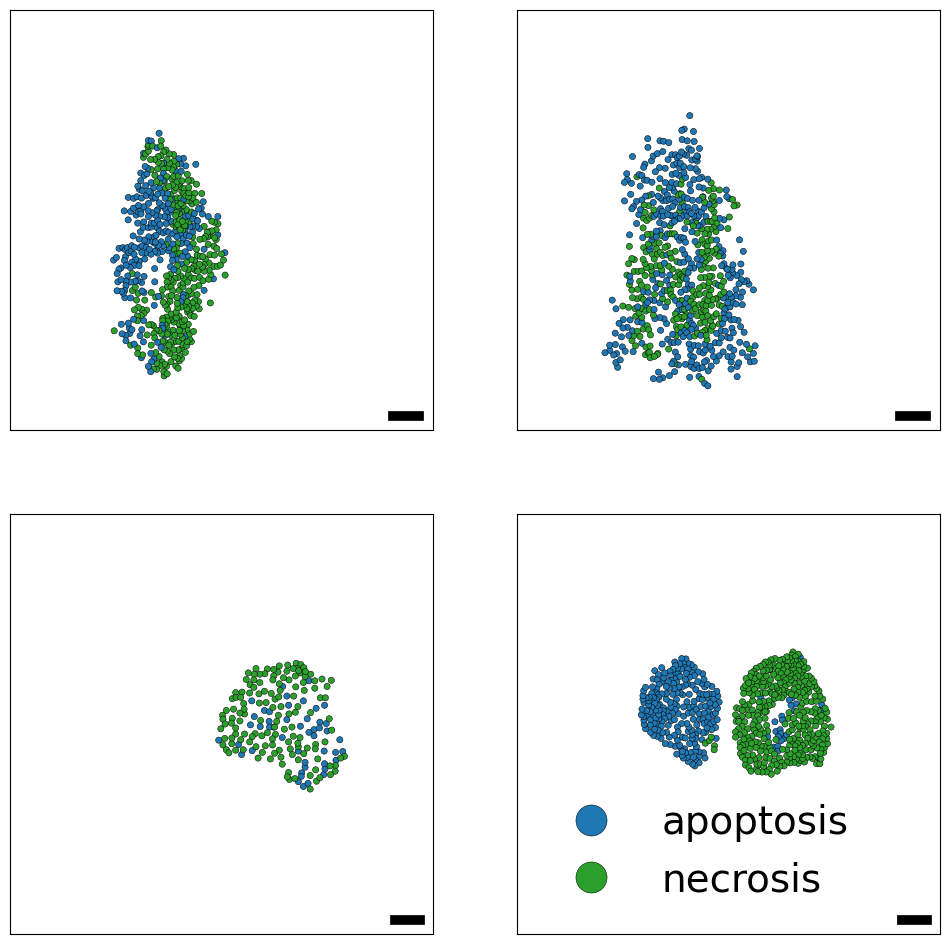

In [18]:
import pandas as pd
import seaborn as sns
import os
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

custom_palette = {"apoptosis": "#1f77b4", "necrosis": "#2ca02c", "other": "lightgray"}

# Create a 2x2 subplot grid
fig, axs = plt.subplots(2, 2, figsize=(12, 12), sharex=True, sharey=True)

# Flatten the axs array for easier indexing
axs = axs.flatten()

# Initialize a counter for subplot index
subplot_idx = 0

# Iterate over each file in exp_names
for file_name in exp_names:
    if 'mixed' not in file_name:
        continue  # Skip files that do not contain 'mixed'
    
    # Get metadata for the current file
    metadata = meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"] == file_name]
    if metadata.empty:
        print(f"Metadata not found for {file_name}. Skipping...")
        continue
    
    size_x = int(metadata["SizeX"].values[0])
    size_y = int(metadata["SizeY"].values[0])
    physical_size_x = float(metadata["PhysicalSizeX"].values[0])
    physical_size_y = float(metadata["PhysicalSizeY"].values[0])
    
    # Construct the full file path
    file_path = os.path.join(exps_dir_name, file_name)
    if not os.path.exists(file_path):
        print(f"File {file_path} not found. Skipping...")
        continue

    # Read the CSV file
    data = pd.read_csv(file_path)
    data = data[data["Mode"].str.lower().isin(["apoptosis", "necrosis", "apoptotic", "necrotic"])]
    legend_labels = {"apoptotic": "apoptosis", "necrotic": "necrosis"}
    data["Mode"] = data["Mode"].replace(legend_labels)
    if data.empty:
        print(f"No valid data in {file_name}. Skipping...")
        continue
    
    x_limit = (0, physical_size_x * size_x)
    y_limit = (0, physical_size_y * size_y)

    # Plot combined modes with their respective shades
    sns.scatterplot(
        ax=axs[subplot_idx],
        data=data,
        x="cell_x",
        y="cell_y",
        hue="Mode",
        palette=custom_palette,
        edgecolor="black",
        s=20,
    )
    axs[subplot_idx].set_xlim(x_limit)
    axs[subplot_idx].set_ylim(y_limit)

    # Remove x and y ticks and labels
    axs[subplot_idx].tick_params(axis='both', which='both', length=0, labelbottom=False, labelleft=False)
    # axs[subplot_idx].set_title(f"File: {file_name}")
    axs[subplot_idx].set_xlabel("", fontsize=24)
    axs[subplot_idx].set_ylabel("", fontsize=24)
    # Add a scale bar at the lower-right corner
    scale_bar_length = 100  # Length of the scale bar
    scale_bar_x = x_limit[1] - scale_bar_length - 50  # Position of the scale bar (x-coordinate)
    scale_bar_y = y_limit[0] + 40  # Position of the scale bar (y-coordinate)
    axs[subplot_idx].add_line(Line2D([scale_bar_x, scale_bar_x + scale_bar_length], 
                                     [scale_bar_y, scale_bar_y], 
                                     color="black", linewidth=7))
    axs[subplot_idx].set_facecolor('none')
    # Remove legend for all but the last subplot
    if subplot_idx == 3:
        axs[subplot_idx].legend(loc="lower left", fontsize=28, scatterpoints=8, markerscale=5, frameon=False)
    else:
        axs[subplot_idx].get_legend().remove()

    # Increment subplot index
    subplot_idx += 1

    # Stop if all subplots are filled
    if subplot_idx >= len(axs):
        break

# Adjust layout and show the plots
# plt.tight_layout()
plt.savefig(f"/home/esraan/CellDeathSpreading/results/combined_plots_with_scalebar.svg", format="svg", facecolor='none')
plt.show()

### adjustable space inbetween

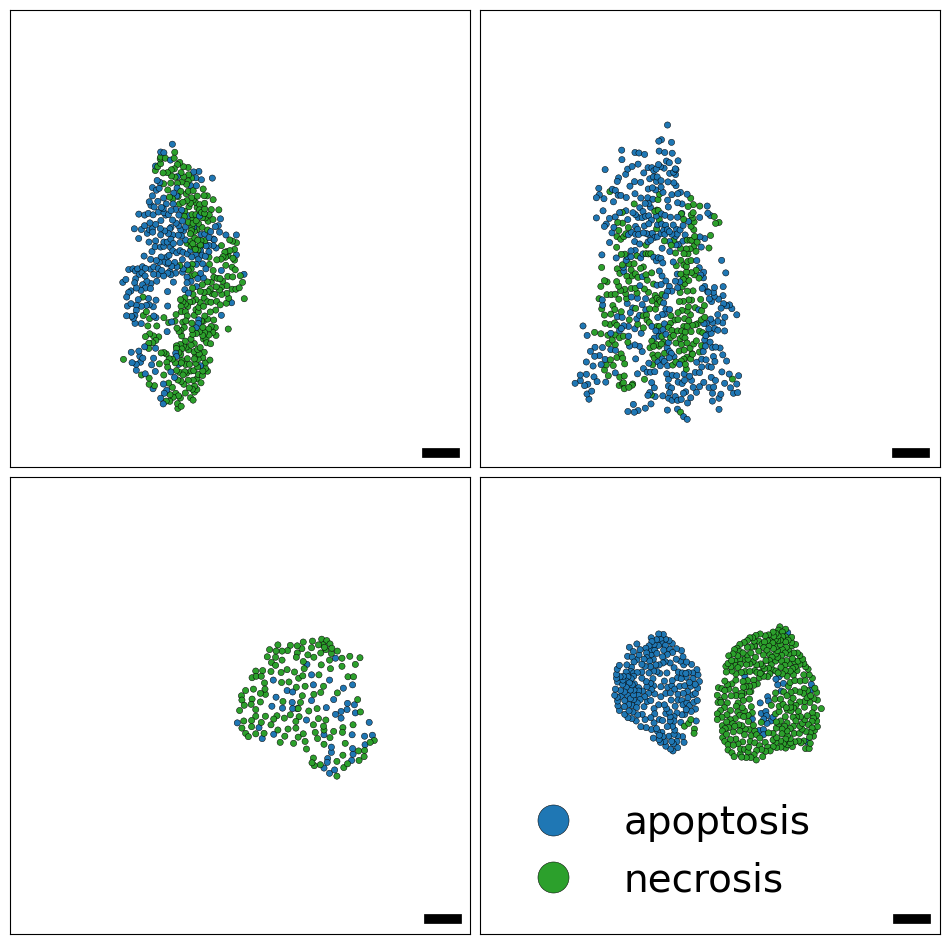

In [17]:
import pandas as pd
import seaborn as sns
import os
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

custom_palette = {"apoptosis": "#1f77b4", "necrosis": "#2ca02c", "other": "lightgray"}

# Initialize lists to store subplot aspect ratios
aspect_ratios = []

# Calculate aspect ratios for each file
for file_name in exp_names:
    if 'mixed' not in file_name:
        continue  # Skip files that do not contain 'mixed'

    # Get metadata for the current file
    metadata = meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"] == file_name]
    if metadata.empty:
        print(f"Metadata not found for {file_name}. Skipping...")
        continue

    size_x = int(metadata["SizeX"].values[0])
    size_y = int(metadata["SizeY"].values[0])
    physical_size_x = float(metadata["PhysicalSizeX"].values[0])
    physical_size_y = float(metadata["PhysicalSizeY"].values[0])

    # Calculate aspect ratio (height/width)
    aspect_ratios.append(physical_size_y * size_y / (physical_size_x * size_x))

# Normalize aspect ratios to sum to 1
aspect_ratios = [ar / sum(aspect_ratios) for ar in aspect_ratios]

# Create a 2x2 subplot grid with proportional aspect ratios
fig, axs = plt.subplots(
    2, 2, figsize=(12, 12), sharex=True, sharey=True,
    gridspec_kw={"height_ratios": aspect_ratios[:2], "width_ratios": aspect_ratios[:2]}
)

# Flatten the axs array for easier indexing
axs = axs.flatten()

# Initialize a counter for subplot index
subplot_idx = 0

# Iterate over each file in exp_names
for file_name in exp_names:
    if 'mixed' not in file_name:
        continue  # Skip files that do not contain 'mixed'

    # Get metadata for the current file
    metadata = meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"] == file_name]
    if metadata.empty:
        print(f"Metadata not found for {file_name}. Skipping...")
        continue

    size_x = int(metadata["SizeX"].values[0])
    size_y = int(metadata["SizeY"].values[0])
    physical_size_x = float(metadata["PhysicalSizeX"].values[0])
    physical_size_y = float(metadata["PhysicalSizeY"].values[0])

    # Construct the full file path
    file_path = os.path.join(exps_dir_name, file_name)
    if not os.path.exists(file_path):
        print(f"File {file_path} not found. Skipping...")
        continue

    # Read the CSV file
    data = pd.read_csv(file_path)
    data = data[data["Mode"].str.lower().isin(["apoptosis", "necrosis", "apoptotic", "necrotic"])]
    legend_labels = {"apoptotic": "apoptosis", "necrotic": "necrosis"}
    data["Mode"] = data["Mode"].replace(legend_labels)
    if data.empty:
        print(f"No valid data in {file_name}. Skipping...")
        continue

    x_limit = (0, physical_size_x * size_x)
    y_limit = (0, physical_size_y * size_y)

    # Plot combined modes with their respective shades
    sns.scatterplot(
        ax=axs[subplot_idx],
        data=data,
        x="cell_x",
        y="cell_y",
        hue="Mode",
        palette=custom_palette,
        edgecolor="black",
        s=20,
    )
    axs[subplot_idx].set_xlim(x_limit)
    axs[subplot_idx].set_ylim(y_limit)

    # Remove x and y ticks and labels
    axs[subplot_idx].tick_params(axis='both', which='both', length=0, labelbottom=False, labelleft=False)
    axs[subplot_idx].set_xlabel("", fontsize=24)
    axs[subplot_idx].set_ylabel("", fontsize=24)

    # Add a scale bar at the lower-right corner
    scale_bar_length = 100  # Length of the scale bar
    scale_bar_x = x_limit[1] - scale_bar_length - 50  # Position of the scale bar (x-coordinate)
    scale_bar_y = y_limit[0] + 40  # Position of the scale bar (y-coordinate)
    axs[subplot_idx].add_line(Line2D([scale_bar_x, scale_bar_x + scale_bar_length],
                                     [scale_bar_y, scale_bar_y],
                                     color="black", linewidth=7))
    axs[subplot_idx].set_facecolor('none')

    # Remove legend for all but the last subplot
    if subplot_idx == 3:
        axs[subplot_idx].legend(loc="lower left", fontsize=28, scatterpoints=8, markerscale=5, frameon=False)
    else:
        axs[subplot_idx].get_legend().remove()

    # Increment subplot index
    subplot_idx += 1

    # Stop if all subplots are filled
    if subplot_idx >= len(axs):
        break

# Adjust layout and show the plots
plt.subplots_adjust(wspace=0.02, hspace=0.02)  # Minimize space between subplots
plt.savefig(f"/home/esraan/CellDeathSpreading/results/combined_plots_with_scalebar.svg", format="svg", facecolor='none')
plt.show()

### Voroni diagram:

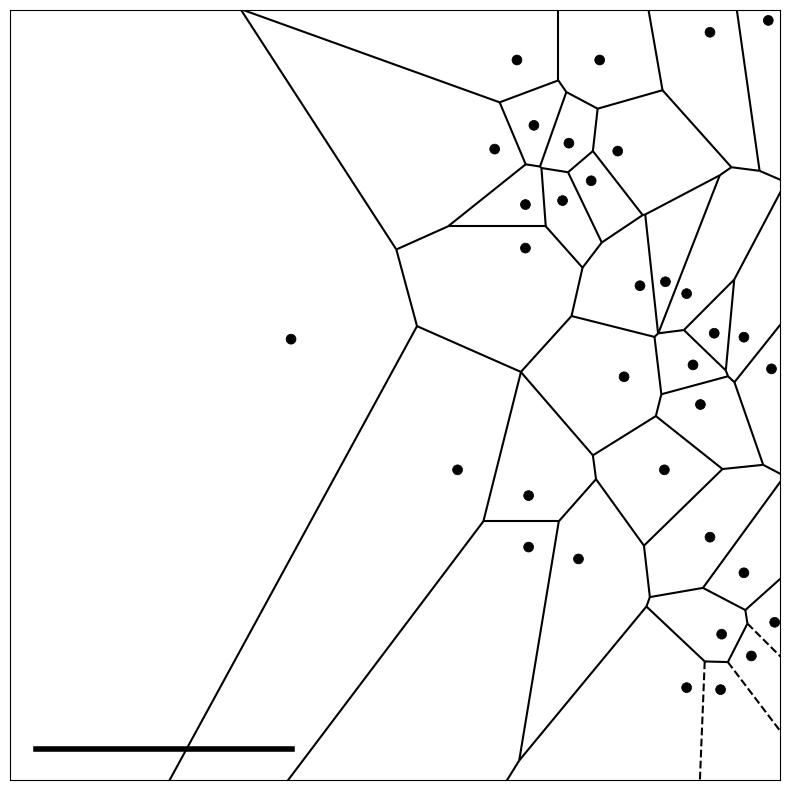

In [36]:
from scipy.spatial import Voronoi, voronoi_plot_2d
import pandas as pd
import seaborn as sns
import os
import matplotlib.pyplot as plt

# Get the first file in the dataset
file_name = exp_names.iloc[1]

# Get metadata for the current file
metadata = meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"] == file_name]
if metadata.empty:
    print(f"Metadata not found for {file_name}. Exiting...")
else:
    size_x = int(metadata["SizeX"].values[0])
    size_y = int(metadata["SizeY"].values[0])
    physical_size_x = float(metadata["PhysicalSizeX"].values[0])
    physical_size_y = float(metadata["PhysicalSizeY"].values[0])

    # Construct the full file path
    file_path = os.path.join(exps_dir_name, file_name)
    if not os.path.exists(file_path):
        print(f"File {file_path} not found. Exiting...")
    else:
        # Read the CSV file
        data = pd.read_csv(file_path)
        data = data[data["Mode"].str.lower().isin(["apoptosis", "necrosis", "apoptotic", "necrotic"])]
        legend_labels = {"apoptotic": "apoptosis", "necrotic": "necrosis"}
        data["Mode"] = data["Mode"].replace(legend_labels)
        if data.empty:
            print(f"No valid data in {file_name}. Exiting...")
        else:
            # Define the cropped area (upper-left corner)
            crop_x_limit = (300, 600)  # 25% of the x-axis
            crop_y_limit = (150, 400)  # Top 25% of the y-axis

            # Filter data for the cropped area
            cropped_data = data[
                (data["cell_x"] >= crop_x_limit[0]) & (data["cell_x"] <= crop_x_limit[1]) &
                (data["cell_y"] >= crop_y_limit[0]) & (data["cell_y"] <= crop_y_limit[1])
            ]

            # Extract points for Voronoi diagram
            points = cropped_data[["cell_x", "cell_y"]].values

            # Check if there are enough points to create a Voronoi diagram
            if len(points) < 3:
                print(f"Not enough points to create a Voronoi diagram for {file_name}. Skipping...")
            else:
                # Create Voronoi diagram
                vor = Voronoi(points)

                # Plot the Voronoi diagram
                fig, ax = plt.subplots(figsize=(8, 8))
                voronoi_plot_2d(vor, ax=ax, show_vertices=False, line_colors='black',show_points=False, line_width=1.5)

                # Overlay the scatter plot
                sns.scatterplot(
                    ax=ax,
                    data=cropped_data,
                    x="cell_x",
                    y="cell_y",
                    hue="Mode",
                    palette={"apoptosis": "black", "necrosis": "black"},
                    edgecolor="black",
                    s=50
                )

                # Set limits to match the cropped area
                ax.set_xlim(crop_x_limit)
                ax.set_ylim(crop_y_limit)
                ax.get_legend().remove()
                # Remove x and y ticks and labels
                ax.tick_params(axis='both', which='both', length=0, labelbottom=False, labelleft=False)
                ax.set_xlabel("", fontsize=24)
                ax.set_ylabel("", fontsize=24)
                # Add a scale bar at the lower-right corner of the cropped area
                scale_bar_length = 100  # Length of the scale bar
                scale_bar_x = crop_x_limit[0]  + 10
                scale_bar_y = crop_y_limit[0] + 10
                ax.add_line(plt.Line2D([scale_bar_x, scale_bar_x + scale_bar_length],
                                       [scale_bar_y, scale_bar_y],
                                       color="black", linewidth=4))
                ax.set_facecolor('none')
                # Save and show the plot
                plt.tight_layout()
                plt.savefig(f"/home/esraan/CellDeathSpreading/results/voronoi_diagram_cropped.svg", format="svg", facecolor='none')
                plt.show()

### ratio-adapted of the plot

In [3]:
exp_names_u = exp_names[exp_names.str.contains('mixed')].reset_index(drop=True)
exp_names_u =[exp_names_u[3], exp_names_u[0],exp_names_u[2],exp_names_u[1]]
exp_names_u

['7-20-23_10arednuclei_ROI#13_or14_both_colonies_annotation_mixed.csv',
 'field13_crop-001_ROI#1_annotation_mixed.csv',
 '7-20-23_10arednuclei_ROI#10_annotation_mixed.csv',
 'Field14-002_ROI#1_annotation_mixed.csv']

### original order, original colors

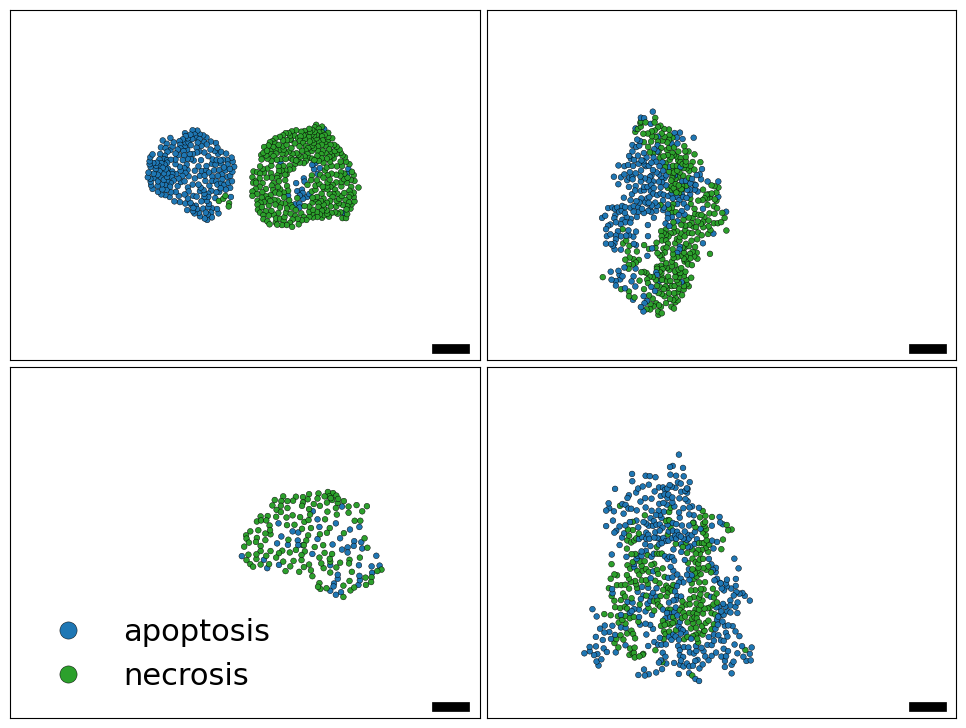

In [4]:
import pandas as pd
import seaborn as sns
import os
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

custom_palette = {"apoptosis": "#1f77b4", "necrosis": "#2ca02c", "other": "lightgray"}
# custom_palette = {"apoptosis": "#bf7745", "necrosis": "#fcf1c5"}
# custom_palette_2 = {"apoptosis": "#6d160d", "necrosis": "#d2ad78"}

# Create a 2x2 subplot grid
fig, axs = plt.subplots(2, 2, figsize=(12.3, 9.2), sharex=False, sharey=False)

# Flatten the axs array for easier indexing
axs = axs.flatten()

# Initialize a counter for subplot index
subplot_idx = 0

# Iterate over each file in exp_names
for file_name in exp_names_u:
    if 'mixed' not in file_name:
        continue  # Skip files that do not contain 'mixed'

    # Get metadata for the current file
    metadata = meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"] == file_name]
    if metadata.empty:
        print(f"Metadata not found for {file_name}. Skipping...")
        continue

    size_x = int(metadata["SizeX"].values[0])
    size_y = int(metadata["SizeY"].values[0])
    physical_size_x = float(metadata["PhysicalSizeX"].values[0])
    physical_size_y = float(metadata["PhysicalSizeY"].values[0])

    # Calculate x and y limits
    x_limit = (0, size_x * physical_size_x)
    y_limit = (0, size_y * physical_size_y)

    # Construct the full file path
    file_path = os.path.join(exps_dir_name, file_name)
    if not os.path.exists(file_path):
        print(f"File {file_path} not found. Skipping...")
        continue

    # Read the CSV file
    data = pd.read_csv(file_path)
    data = data[data["Mode"].str.lower().isin(["apoptosis", "necrosis", "apoptotic", "necrotic"])]
    legend_labels = {"apoptotic": "apoptosis", "necrotic": "necrosis"}
    data["Mode"] = data["Mode"].replace(legend_labels)
    if data.empty:
        print(f"No valid data in {file_name}. Skipping...")
        continue

    # Plot combined modes with their respective shades
    sns.scatterplot(
        ax=axs[subplot_idx],
        data=data,
        x="cell_x",
        y="cell_y",
        hue="Mode",
        palette=custom_palette,
        edgecolor="black",
        s=17,
    )
    axs[subplot_idx].set_xlim(x_limit)
    axs[subplot_idx].set_ylim(y_limit)

    # Set the aspect ratio to preserve the original ratio
    aspect_ratio = (x_limit[1] - x_limit[0]) / (y_limit[1] - y_limit[0])
    axs[subplot_idx].set_box_aspect(1 / aspect_ratio)

    # axs[subplot_idx].set_aspect(aspect_ratio)

    # Remove x and y ticks and labels
    axs[subplot_idx].tick_params(axis='both', which='both', length=0, labelbottom=False, labelleft=False)
    axs[subplot_idx].set_xlabel("", fontsize=24)
    axs[subplot_idx].set_ylabel("", fontsize=24)

    # Add a scale bar at the lower-right corner
    scale_bar_length = 100  # Length of the scale bar
    scale_bar_x = x_limit[1] - scale_bar_length - 50  # Position of the scale bar (x-coordinate)
    scale_bar_y = y_limit[0] + 40  # Position of the scale bar (y-coordinate)
    axs[subplot_idx].add_line(Line2D([scale_bar_x, scale_bar_x + scale_bar_length],
                                     [scale_bar_y, scale_bar_y],
                                     color="black", linewidth=7))
    axs[subplot_idx].set_facecolor('none')

    # Remove legend for all but the last subplot
    if subplot_idx == 2:
        axs[subplot_idx].legend(loc="lower left", fontsize=22, scatterpoints=5, markerscale=3, frameon=False)
    else:
        axs[subplot_idx].get_legend().remove()

    # Increment subplot index
    subplot_idx += 1

    # Stop if all subplots are filled
    if subplot_idx >= len(axs):
        break

# Adjust layout and show the plots
# plt.tight_layout()
plt.subplots_adjust(wspace=0.0001, hspace=0.02)  # Minimize space between subplots
plt.savefig(f"/home/esraan/CellDeathSpreading/results/combined_plots_with_scalebar_rearranged_n.svg", format="svg", facecolor='none')
plt.show()

### rearranged colored diffrently

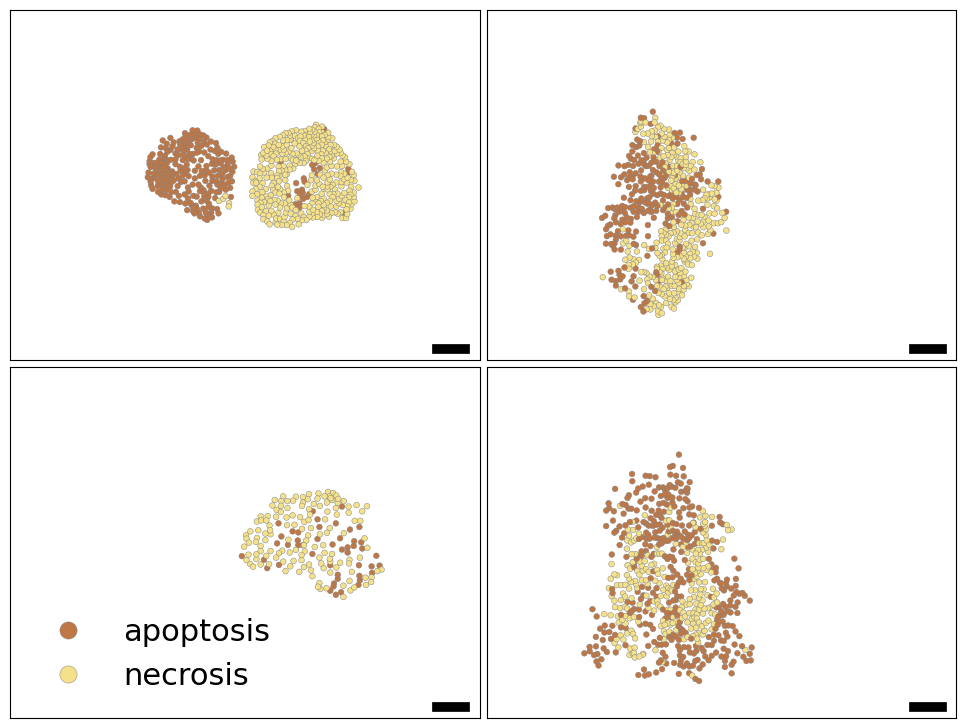

In [37]:
import pandas as pd
import seaborn as sns
import os
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

custom_palette = {"apoptosis": "#1f77b4", "necrosis": "#2ca02c", "other": "lightgray"}
custom_palette = {"apoptosis": "#bf7745", "necrosis": "#f5e18a"} ##fcf1c5
# custom_palette = {"apoptosis": "#6d160d", "necrosis": "#d2ad78"}

# Create a 2x2 subplot grid
fig, axs = plt.subplots(2, 2, figsize=(12.3, 9.2), sharex=False, sharey=False)

# Flatten the axs array for easier indexing
axs = axs.flatten()

# Initialize a counter for subplot index
subplot_idx = 0

# Iterate over each file in exp_names
for file_name in exp_names_u:
    if 'mixed' not in file_name:
        continue  # Skip files that do not contain 'mixed'

    # Get metadata for the current file
    metadata = meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"] == file_name]
    if metadata.empty:
        print(f"Metadata not found for {file_name}. Skipping...")
        continue

    size_x = int(metadata["SizeX"].values[0])
    size_y = int(metadata["SizeY"].values[0])
    physical_size_x = float(metadata["PhysicalSizeX"].values[0])
    physical_size_y = float(metadata["PhysicalSizeY"].values[0])

    # Calculate x and y limits
    x_limit = (0, size_x * physical_size_x)
    y_limit = (0, size_y * physical_size_y)

    # Construct the full file path
    file_path = os.path.join(exps_dir_name, file_name)
    if not os.path.exists(file_path):
        print(f"File {file_path} not found. Skipping...")
        continue

    # Read the CSV file
    data = pd.read_csv(file_path)
    data = data[data["Mode"].str.lower().isin(["apoptosis", "necrosis", "apoptotic", "necrotic"])]
    legend_labels = {"apoptotic": "apoptosis", "necrotic": "necrosis"}
    data["Mode"] = data["Mode"].replace(legend_labels)
    if data.empty:
        print(f"No valid data in {file_name}. Skipping...")
        continue
    # data['EdgeColor'] = data['Mode'].map(custom_palette_2)
    # Plot combined modes with their respective shades
    sns.scatterplot(
        ax=axs[subplot_idx],
        data=data,
        x="cell_x",
        y="cell_y",
        hue="Mode",
        palette=custom_palette,
        edgecolor='gray',
        s=17,
    )
    axs[subplot_idx].set_xlim(x_limit)
    axs[subplot_idx].set_ylim(y_limit)

    # Set the aspect ratio to preserve the original ratio
    aspect_ratio = (x_limit[1] - x_limit[0]) / (y_limit[1] - y_limit[0])
    axs[subplot_idx].set_box_aspect(1 / aspect_ratio)

    # axs[subplot_idx].set_aspect(aspect_ratio)

    # Remove x and y ticks and labels
    axs[subplot_idx].tick_params(axis='both', which='both', length=0, labelbottom=False, labelleft=False)
    axs[subplot_idx].set_xlabel("", fontsize=24)
    axs[subplot_idx].set_ylabel("", fontsize=24)

    # Add a scale bar at the lower-right corner
    scale_bar_length = 100  # Length of the scale bar
    scale_bar_x = x_limit[1] - scale_bar_length - 50  # Position of the scale bar (x-coordinate)
    scale_bar_y = y_limit[0] + 40  # Position of the scale bar (y-coordinate)
    axs[subplot_idx].add_line(Line2D([scale_bar_x, scale_bar_x + scale_bar_length],
                                     [scale_bar_y, scale_bar_y],
                                     color="black", linewidth=7))
    axs[subplot_idx].set_facecolor('none')

    # Remove legend for all but the last subplot
    if subplot_idx == 2:
        axs[subplot_idx].legend(loc="lower left", fontsize=22, scatterpoints=5, markerscale=3, frameon=False)
    else:
        axs[subplot_idx].get_legend().remove()

    # Increment subplot index
    subplot_idx += 1

    # Stop if all subplots are filled
    if subplot_idx >= len(axs):
        break

# Adjust layout and show the plots
# plt.tight_layout()
plt.subplots_adjust(wspace=0.0001, hspace=0.02)  # Minimize space between subplots
plt.savefig(f"/home/esraan/CellDeathSpreading/results/combined_plots_with_scalebar_rearranged.svg", format="svg", facecolor='none')
plt.show()

In [24]:
data['EdgeColor'].isna().any()

False

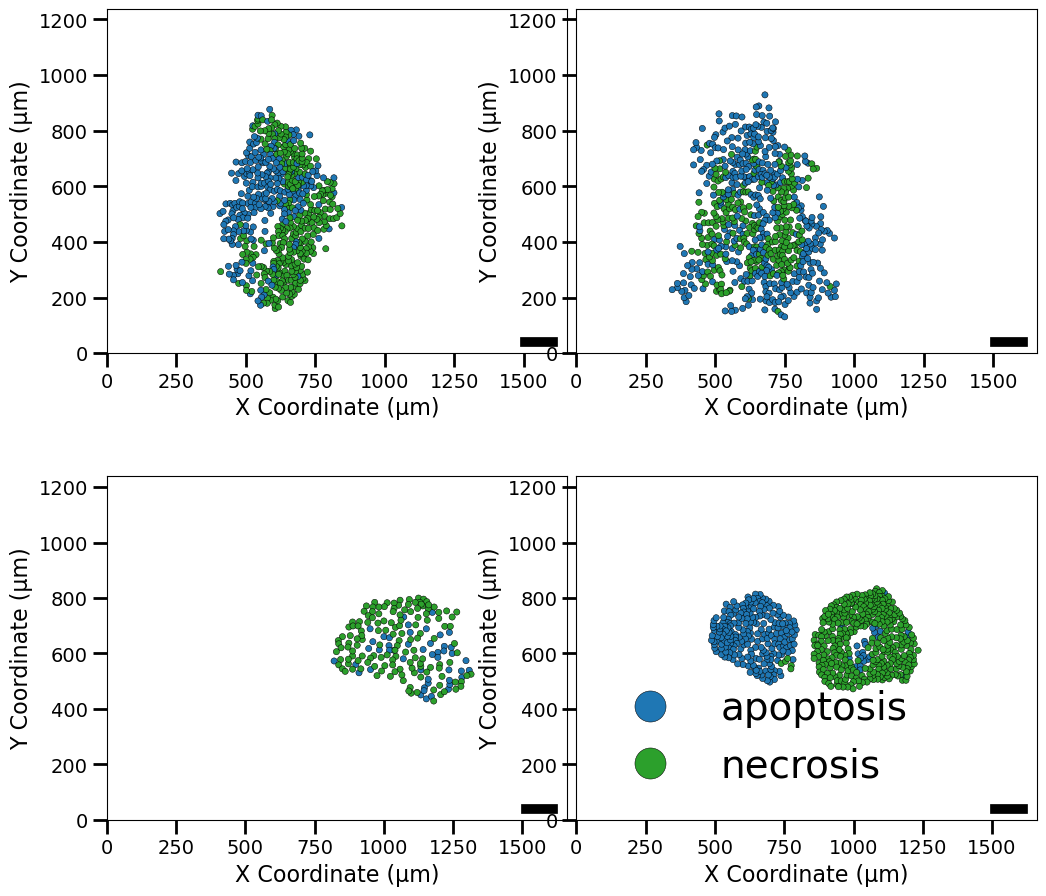

In [25]:
import pandas as pd
import seaborn as sns
import os
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

custom_palette = {"apoptosis": "#1f77b4", "necrosis": "#2ca02c", "other": "lightgray"}

# Create a 2x2 subplot grid
fig, axs = plt.subplots(2, 2, figsize=(12, 12), sharex=False, sharey=False)

# Flatten the axs array for easier indexing
axs = axs.flatten()

# Initialize a counter for subplot index
subplot_idx = 0

# Iterate over each file in exp_names
for file_name in exp_names:
    if 'mixed' not in file_name:
        continue  # Skip files that do not contain 'mixed'

    # Get metadata for the current file
    metadata = meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"] == file_name]
    if metadata.empty:
        print(f"Metadata not found for {file_name}. Skipping...")
        continue

    size_x = int(metadata["SizeX"].values[0])
    size_y = int(metadata["SizeY"].values[0])
    physical_size_x = float(metadata["PhysicalSizeX"].values[0])
    physical_size_y = float(metadata["PhysicalSizeY"].values[0])

    # Calculate x and y limits
    x_limit = (0, size_x * physical_size_x)
    y_limit = (0, size_y * physical_size_y)

    # Construct the full file path
    file_path = os.path.join(exps_dir_name, file_name)
    if not os.path.exists(file_path):
        print(f"File {file_path} not found. Skipping...")
        continue

    # Read the CSV file
    data = pd.read_csv(file_path)
    data = data[data["Mode"].str.lower().isin(["apoptosis", "necrosis", "apoptotic", "necrotic"])]
    legend_labels = {"apoptotic": "apoptosis", "necrotic": "necrosis"}
    data["Mode"] = data["Mode"].replace(legend_labels)
    if data.empty:
        print(f"No valid data in {file_name}. Skipping...")
        continue

    # Plot combined modes with their respective shades
    sns.scatterplot(
        ax=axs[subplot_idx],
        data=data,
        x="cell_x",
        y="cell_y",
        hue="Mode",
        palette=custom_palette,
        edgecolor="black",
        s=20,
    )
    axs[subplot_idx].set_xlim(x_limit)
    axs[subplot_idx].set_ylim(y_limit)

    # Set the aspect ratio to preserve the original ratio
    aspect_ratio = (x_limit[1] - x_limit[0]) / (y_limit[1] - y_limit[0])
    axs[subplot_idx].set_box_aspect(1 / aspect_ratio)


    # Remove x and y ticks and labels
    axs[subplot_idx].tick_params(axis='both', which='both', length=0, labelbottom=False, labelleft=False)
    axs[subplot_idx].set_xlabel("", fontsize=24)
    axs[subplot_idx].set_ylabel("", fontsize=24)
    axs[subplot_idx].tick_params(axis='both', which='both', length=5, labelbottom=True, labelleft=True)
    # Add tick marks and labels for both axes
    axs[subplot_idx].tick_params(axis='both', which='major', length=10, width=2, labelsize=14)
    axs[subplot_idx].set_xlabel("X Coordinate (µm)", fontsize=16)
    axs[subplot_idx].set_ylabel("Y Coordinate (µm)", fontsize=16)
    # Add a scale bar at the lower-right corner
    scale_bar_length = 100  # Length of the scale bar
    scale_bar_x = x_limit[1] - scale_bar_length - 50  # Position of the scale bar (x-coordinate)
    scale_bar_y = y_limit[0] + 40  # Position of the scale bar (y-coordinate)
    axs[subplot_idx].add_line(Line2D([scale_bar_x, scale_bar_x + scale_bar_length],
                                     [scale_bar_y, scale_bar_y],
                                     color="black", linewidth=7))
    axs[subplot_idx].set_facecolor('none')

    # Remove legend for all but the last subplot
    if subplot_idx == 3:
        axs[subplot_idx].legend(loc="lower left", fontsize=28, scatterpoints=8, markerscale=5, frameon=False)
    else:
        axs[subplot_idx].get_legend().remove()

    # Increment subplot index
    subplot_idx += 1

    # Stop if all subplots are filled
    if subplot_idx >= len(axs):
        break

# Adjust layout and show the plots
plt.subplots_adjust(wspace=0.02, hspace=0.02)  # Minimize space between subplots
plt.savefig(f"/home/esraan/CellDeathSpreading/results/combined_plots_with_scalebar.svg", format="svg", facecolor='none')
plt.show()